# nb06 — EDA per Parking & Categorie
**Masterproef:** Tier-Stratified Occupancy Prediction and Scenario-Based Policy Simulation  
**Auteur:** Emile Van de Voorde  
**Dataset:** MAD_shortterm.parquet + MAD_longterm.parquet  
**Trainingsset:** 129.837 rijen (jaren 2020/2023/2024, kwaliteitsflags=0)  
**Doel:** Blootleggen van ruimtelijke heterogeniteit tussen de 10 parkings en
tussen de 2 tiers (centrum vs. vesten_of_rand), toetsing van H-S1 t/m H-S4,
en identificatie van parking-specifieke features voor nb08.

---

### Tier-definitie (conform nb05)
| Tier (origineel) | Tier (nb06) | Parkings | N capaciteit |
|---|---|---|---|
| centrum | centrum | P Grote Markt, P Hoogstraat, P Kathedraal, P Lamot, P Veemarkt | 778 pl. |
| vesten | vesten_of_rand | P Bruul, P Komet, P Maarten, P Tinel | 787 pl. |
| rand | vesten_of_rand | P Keerdok | 516 pl. |

**Motivatie samenvoeging:** Slechts 1 rand-parking (P Keerdok, 516 pl.) is
statistisch onvoldoende voor een aparte tier-categorie. Kruskal-Wallis en
regressie-analyses vereisen ≥2 onafhankelijke eenheden per groep
(Field, 2013; Conover, 1999).

**Let op:** P Zandpoortvest (622 pl., vesten) is aanwezig in locatietabel
maar heeft GEEN tijdreeksdata → de vesten-tier is onderschat in totale
capaciteit. Dit is een expliciete databegrenzing (zie cel 02).

---

### Hypothesen getoetst in dit notebook
| Code | Hypothese | Cel | Toets |
|---|---|---|---|
| H-S1 | Centrum hogere gemiddelde + piekbezetting (p90) | 02, 04 | Kruskal-Wallis + Dunn post-hoc |
| H-S2 | Negatieve correlatie capaciteit × bezetting | 03, 05 | Spearman ρ + regressie |
| H-S3 | Intra-tier correlatie > inter-tier correlatie | 06 | Pearson r + Fischer z-test |
| H-S4 | Eventeffect groter voor centrum dan vesten_of_rand | 08 | Mann-Whitney U + Cohen's d |


In [4]:
# ─── Cel 01: Config + data laden ─────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Paden ─────────────────────────────────────────────────────────────────────
ROOT      = Path("/Users/emilevandevoorde/Documents/mechelen_parking")
DATA_PROC = ROOT / "data_processed"
DATA_INT  = ROOT / "data_intermediate"
FIGS      = ROOT / "figures" / "eda" / "nb06"
FIGS.mkdir(parents=True, exist_ok=True)

# ── Data laden ────────────────────────────────────────────────────────────────
df_short = pd.read_parquet(DATA_PROC / "MAD_shortterm.parquet")
df_long  = pd.read_parquet(DATA_PROC / "MAD_longterm.parquet")

# ── Trainingsfilter (conform eda_config — NIET WIJZIGEN) ──────────────────────
def get_train_mask(df):
    return (
        (df["low_data_coverage"] == 0) &
        (df["system_blackout"]   == 0) &
        (df["partial_year"]      == 0) &
        (df["year"]              >= 2020) &
        (df["year"]              != 2025)
    )

df_train = df_short[get_train_mask(df_short)].copy()

# ── Tier-samenvoeging: vesten + rand → vesten_of_rand ─────────────────────────
# .astype(str) eerst: parking_location_category is Categorical dtype
df_train["tier"] = (
    df_train["parking_location_category"]
    .astype(str)
    .replace({"rand": "vesten_of_rand", "vesten": "vesten_of_rand"})
)

# ── Gedeelde constanten ───────────────────────────────────────────────────────
TIER_ORDER  = ["centrum", "vesten_of_rand"]
TIER_COLORS = {"centrum": "#2563EB", "vesten_of_rand": "#16A34A"}

# Vaste parkeervolgorde: centrum eerst, dan vesten, dan rand (op capaciteit)
PARKING_ORDER = [
    "P Grote Markt", "P Hoogstraat", "P Kathedraal", "P Lamot", "P Veemarkt",  # centrum
    "P Bruul", "P Komet", "P Maarten", "P Tinel",                               # vesten
    "P Keerdok",                                                                  # rand
]
PARKING_TIER_MAP = {
    "P Grote Markt": "centrum", "P Hoogstraat": "centrum",
    "P Kathedraal":  "centrum", "P Lamot":      "centrum",
    "P Veemarkt":    "centrum", "P Bruul":       "vesten_of_rand",
    "P Komet":       "vesten_of_rand", "P Maarten": "vesten_of_rand",
    "P Tinel":       "vesten_of_rand", "P Keerdok": "vesten_of_rand",
}
PARKING_COLORS = {
    p: TIER_COLORS["centrum"] if PARKING_TIER_MAP[p] == "centrum"
    else TIER_COLORS["vesten_of_rand"]
    for p in PARKING_ORDER
}

# ── Day_type_3 (conform nb05) ─────────────────────────────────────────────────
df_train["day_type_3"] = "weekday"
df_train.loc[df_train["weekday_int"] == 5, "day_type_3"] = "saturday"
df_train.loc[
    (df_train["weekday_int"] == 6) | (df_train["is_national_holiday"] == 1),
    "day_type_3"
] = "sunday_holiday"

# ── Locatietabel laden voor capaciteit ───────────────────────────────────────
df_loc = pd.read_parquet(DATA_INT / "parking_location_clean.parquet")

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"df_train shape        : {df_train.shape}")
print(f"Jaren                 : {sorted(df_train['year'].unique())}")
print(f"Aantal parkings       : {df_train['parking_id'].nunique()}")
print(f"\nRijen per tier:")
print(df_train["tier"].value_counts())
print(f"\nRijen per parking:")
print(df_train.groupby("parking_id")["occupancy_rate"].count().reindex(PARKING_ORDER))
print(f"\nOccupancy_rate range  : [{df_train['occupancy_rate'].min():.3f}, "
      f"{df_train['occupancy_rate'].max():.3f}]")
print(f"Ontbrekende waarden   : {df_train['occupancy_rate'].isna().sum()}")


df_train shape        : (129837, 65)
Jaren                 : [np.int32(2020), np.int32(2023), np.int32(2024)]
Aantal parkings       : 10

Rijen per tier:
tier
centrum           73093
vesten_of_rand    56744
Name: count, dtype: int64

Rijen per parking:
parking_id
P Grote Markt    19044
P Hoogstraat     12954
P Kathedraal     12232
P Lamot          14013
P Veemarkt       14850
P Bruul          12709
P Komet           3126
P Maarten         5944
P Tinel          18155
P Keerdok        16810
Name: occupancy_rate, dtype: int64

Occupancy_rate range  : [0.000, 1.000]
Ontbrekende waarden   : 0


## Cel 02 — Beschrijvende statistieken per parking
### Hypothese: H-S1

> "Centrumparkings vertonen structureel **hogere gemiddelde bezetting**
> EN hogere **piekbezetting (p90)** dan vesten_of_rand (Kruskal-Wallis p < 0.01)."

**Statistieken gerapporteerd:**

| Statistiek | Formule | Motivatie |
|---|---|---|
| Gemiddelde | $(\bar{x} = \frac{1}{n}\sum x_i)$ | Centrale tendentie |
| Mediaan | p50 | Robuust voor scheefheid |
| Std. deviatie | $(s = \sqrt{\frac{1}{n-1}\sum(x_i - \bar{x})^2}$) | Spreiding |
| p10, p90 | Empirische percentielen | Structurele dal- en piekbezetting |
| IQR | p75 - p25 | Robuuste spreiding (Tukey, 1977) |
| Skewness | $(\gamma_1 = \frac{m_3}{s^3})$ | Verdeling links/rechtsschief |
| CV (%) | $(CV = \frac{s}{\bar{x}} \times 100$) | Relatieve variabiliteit |

**Kruskal-Wallis toets:**
Niet-parametrische one-way ANOVA op uurobservaties per tier.
H₀: De verdeling van occupancy_rate is identiek voor alle tiers.
H₁: Minstens één tier heeft een andere verdeling.
Keuze niet-parametrisch: bezettingsdata is [0,1]-begrensd en rechtsschief
→ normaliteitsaanname niet haalbaar bij dergelijke verdeling
(Kruskal & Wallis, 1952; Field, 2013).

**Post-hoc: Dunn-toets met Bonferroni-correctie:**
Bij significant Kruskal-Wallis testen we paargewijs welke tiers
significant van elkaar afwijken. Bonferroni-correctie controleert
voor de familywise error rate bij meerdere vergelijkingen
(Dunn, 1964; Abdi, 2010).

**Effect size η² (eta-kwadraat):**
$\eta^2 = \frac{H - k + 1}{n - k}$
waarbij H = Kruskal-Wallis statistiek, k = aantal groepen, n = totale N.
Interpretatie: 0.01=klein, 0.06=medium, 0.14=groot (Cohen, 1988).


In [6]:
# ─── Cel 02: Beschrijvende statistieken per parking ──────────────────────────
from scipy.stats import kruskal, skew, kurtosis, rankdata, norm as sp_norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Beschrijvende stats per parking ───────────────────────────────────────────
stats_rows = []

for pid in PARKING_ORDER:
    if pid not in df_train["parking_id"].values:
        continue
    series = df_train[df_train["parking_id"] == pid]["occupancy_rate"].dropna()
    tier   = PARKING_TIER_MAP.get(pid, "onbekend")
    cap    = df_loc[df_loc["parking_id"] == pid]["total_capacity"].values
    cap    = int(cap[0]) if len(cap) > 0 else np.nan
    
    stats_rows.append({
        "parking_id":    pid,
        "tier":          tier,
        "capacity":      cap,
        "n_obs":         len(series),
        "mean":          round(series.mean(), 4),
        "median":        round(series.median(), 4),
        "std":           round(series.std(), 4),
        "cv_pct":        round(series.std() / series.mean() * 100, 2) if series.mean() > 0 else np.nan,
        "p10":           round(series.quantile(0.10), 4),
        "p25":           round(series.quantile(0.25), 4),
        "p75":           round(series.quantile(0.75), 4),
        "p90":           round(series.quantile(0.90), 4),
        "iqr":           round(series.quantile(0.75) - series.quantile(0.25), 4),
        "skewness":      round(float(skew(series)), 4),
        "kurtosis":      round(float(kurtosis(series)), 4),
        "frac_below_20": round((series < 0.20).mean(), 4),
        "frac_above_80": round((series > 0.80).mean(), 4),
        "frac_full":     round((series >= 0.95).mean(), 4),
    })

df_stats = pd.DataFrame(stats_rows)

# ── Kruskal-Wallis toets: centrum vs. vesten_of_rand ─────────────────────────
groups = [
    df_train[df_train["tier"] == t]["occupancy_rate"].dropna().values
    for t in TIER_ORDER
]
kw_stat, kw_p = kruskal(*groups)

# Effect size η² (eta-kwadraat)
# Formule: η² = (H - k + 1) / (n - k)
# Referentie: Cohen (1988); Tomczak & Tomczak (2014)
n_total = sum(len(g) for g in groups)
k       = len(groups)
eta2    = (kw_stat - k + 1) / (n_total - k)
eta2_label = (
    "groot"  if eta2 >= 0.14 else
    "medium" if eta2 >= 0.06 else
    "klein"  if eta2 >= 0.01 else
    "verwaarloosbaar"
)

print("── Beschrijvende statistieken per parking ──")
display_cols = ["parking_id", "tier", "capacity", "n_obs",
                "mean", "median", "std", "cv_pct",
                "p10", "p90", "iqr", "skewness", "frac_above_80", "frac_full"]
print(df_stats[display_cols].to_string(index=False))

print(f"\n── Kruskal-Wallis toets (tier-vergelijking) ──")
print(f"  H-statistiek : {kw_stat:.4f}")
print(f"  p-waarde     : {kw_p:.4e}")
print(f"  Effect size η²: {eta2:.4f} ({eta2_label})")
print(f"  Conclusie    : {'H-S1 BEVESTIGD (p<0.01)' if kw_p < 0.01 else 'H-S1 NIET BEVESTIGD'}")

# ── Post-hoc: met 2 groepen = KW is al de pairwise toets ─────────────────────
# Aanvullend: Mann-Whitney U met rank-biseriale correlatie als effect size
# Referentie: Field (2013) — bij k=2 groepen is KW equivalent aan Mann-Whitney
from scipy.stats import mannwhitneyu

np.random.seed(42)
g0 = groups[0]
g1 = groups[1]

# Sampling voor snelheid (max 10.000 per groep)
idx0 = np.random.choice(len(g0), size=min(10000, len(g0)), replace=False)
idx1 = np.random.choice(len(g1), size=min(10000, len(g1)), replace=False)
g0s, g1s = g0[idx0], g1[idx1]

mw_stat, mw_p = mannwhitneyu(g0s, g1s, alternative="two-sided")
n1, n2   = len(g0s), len(g1s)
r_rb     = (2 * mw_stat) / (n1 * n2) - 1
r_label  = (
    "groot"  if abs(r_rb) >= 0.5 else
    "medium" if abs(r_rb) >= 0.3 else
    "klein"  if abs(r_rb) >= 0.1 else
    "verwaarloosbaar"
)

print(f"\n── Pairwise Mann-Whitney U: {TIER_ORDER[0]} vs. {TIER_ORDER[1]} ──")
print(f"  (Sampling: {n1} + {n2} obs. | seed=42)")
print(f"  U-statistiek         : {mw_stat:.1f}")
print(f"  p-waarde (twee-zij.) : {mw_p:.4e}")
print(f"  Rank-biseriale r     : {r_rb:.4f} ({r_label})")
print(f"  Mediaan centrum      : {np.median(groups[0]):.1%}")
print(f"  Mediaan vesten_of_rand: {np.median(groups[1]):.1%}")
print(f"  Δ mediaan            : {np.median(groups[0]) - np.median(groups[1]):+.1%}")

# ── Tier-samenvatting ─────────────────────────────────────────────────────────
print(f"\n── Tier-samenvatting ──")
tier_summary = df_stats.groupby("tier").agg(
    n_parkings    = ("parking_id", "count"),
    mean_occ      = ("mean",       "mean"),
    mean_p90      = ("p90",        "mean"),
    mean_cv       = ("cv_pct",     "mean"),
    mean_frac_full= ("frac_full",  "mean")
).round(4)
print(tier_summary.to_string())

# ── Export ────────────────────────────────────────────────────────────────────
df_stats.to_csv(FIGS / "tabel_stats_parking.csv", index=False)
print("\n✓ Opgeslagen: tabel_stats_parking.csv")


── Beschrijvende statistieken per parking ──
   parking_id           tier  capacity  n_obs   mean  median    std  cv_pct    p10    p90    iqr  skewness  frac_above_80  frac_full
P Grote Markt        centrum       155  19044 0.4618  0.4074 0.3130   67.79 0.0815 0.9111 0.5926    0.2580         0.2172     0.0563
 P Hoogstraat        centrum       109  12954 0.2049  0.1583 0.1789   87.31 0.0417 0.4200 0.1583    1.9799         0.0199     0.0073
 P Kathedraal        centrum       130  12232 0.4525  0.3857 0.3410   75.37 0.0571 0.9571 0.6571    0.2674         0.2339     0.1044
      P Lamot        centrum       255  14013 0.4497  0.4213 0.2156   47.95 0.1982 0.7664 0.3064    0.4250         0.0796     0.0118
   P Veemarkt        centrum       129  14850 0.4563  0.4242 0.2611   57.23 0.0989 0.8182 0.4141    0.1869         0.1170     0.0259
      P Bruul vesten_of_rand       350  12709 0.1877  0.0936 0.2292  122.08 0.0117 0.4914 0.1871    1.9249         0.0485     0.0164
      P Komet vesten_of_

## Cel 03 — Verdeling per parking (violin + boxplot overlay)
### Hypothese: H-S2 (visuele basis)

**Doel:** Visualiseren van de volledige empirische verdeling per parking —
niet alleen het gemiddelde, maar de volledige vorm (uni/bimodaal, scheefheid,
staartgedrag).

**Keuze voor violin plot:**
Een violin plot combineert een kernel density estimate (KDE) met een
boxplot overlay. Dit is informatiever dan een pure boxplot omdat:
1. Bimodale verdelingen zichtbaar worden (bv. lege + volle perioden)
2. De vorm van de staarten wordt getoond (relevant voor extreme bezetting)
3. Vergelijking tussen parkings van verschillende schaal mogelijk is

Referentie: Hintze & Nelson (1998) introduceerden de violin plot precies
voor dit doel — het tonen van distributiemodaliteit dat verborgen blijft
in boxplots.

**KDE bandbreedte:** Silverman's rule-of-thumb:
\[ h = 0.9 \cdot \min(s, \text{IQR}/1.34) \cdot n^{-1/5} \]
(Silverman, 1986). Dit is de standaard in matplotlib/seaborn.

**Capaciteitsparadox (H-S2) — visuele check:**
Parkings zijn gesorteerd op capaciteit (klein → groot) binnen elke tier.
Als H-S2 klopt (groter = lager bezet), dan zou de mediaan systematisch
dalen van links naar rechts binnen dezelfde tier.

**Annotaties:** p90-lijn per parking toont het structurele piekbezettingsniveau —
relevant voor beleidsimulaties (RQ2, nb13).


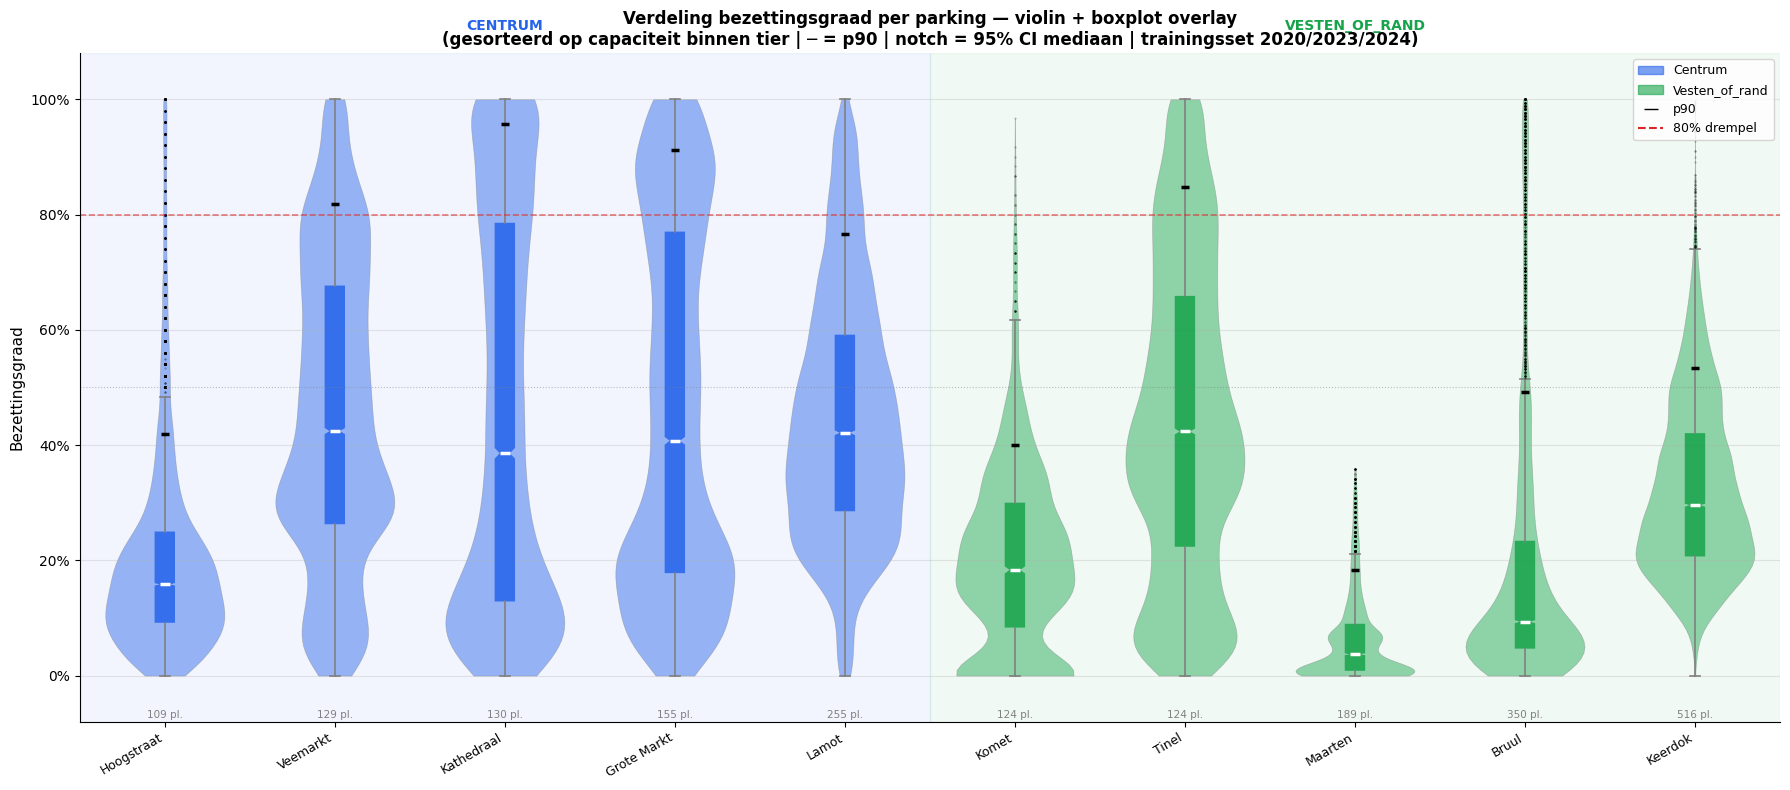

✓ Opgeslagen: fig_distribution.png

── H-S2 visuele check: capaciteit vs. mediaan occupancy (per tier) ──

  Tier centrum:
   parking_id  capacity  median
 P Hoogstraat       109  0.1583
   P Veemarkt       129  0.4242
 P Kathedraal       130  0.3857
P Grote Markt       155  0.4074
      P Lamot       255  0.4213

  Tier vesten_of_rand:
parking_id  capacity  median
   P Komet       124  0.1833
   P Tinel       124  0.4235
 P Maarten       189  0.0370
   P Bruul       350  0.0936
 P Keerdok       516  0.2957


In [7]:
# ─── Cel 03: Violin + boxplot per parking ────────────────────────────────────
import seaborn as sns

# Sorteer binnen tier op capaciteit (klein → groot) voor H-S2 visuele check
df_stats_sorted = df_stats.sort_values(
    ["tier", "capacity"],
    key=lambda col: col.map({"centrum": 0, "vesten_of_rand": 1}) if col.name == "tier" else col
)
PARKING_ORDER_CAP = df_stats_sorted["parking_id"].tolist()

# Bouw plot-dataframe (gesamplede data voor snelheid)
np.random.seed(42)
plot_rows = []
for pid in PARKING_ORDER_CAP:
    vals = df_train[df_train["parking_id"] == pid]["occupancy_rate"].dropna()
    n_sample = min(3000, len(vals))
    sampled  = vals.sample(n_sample, random_state=42)
    plot_rows.append(pd.DataFrame({"parking_id": pid,
                                    "occupancy_rate": sampled.values,
                                    "tier": PARKING_TIER_MAP[pid]}))
df_plot = pd.concat(plot_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(18, 8))

# Tier-achtergrondkleuren
tier_boundaries = {}
for tier in TIER_ORDER:
    idxs = [i for i, p in enumerate(PARKING_ORDER_CAP)
            if PARKING_TIER_MAP.get(p) == tier]
    if idxs:
        tier_boundaries[tier] = (min(idxs), max(idxs))

for tier, (lo, hi) in tier_boundaries.items():
    ax.axvspan(lo - 0.5, hi + 0.5, alpha=0.06,
               color=TIER_COLORS[tier], zorder=0)

# Violin plot
vp = ax.violinplot(
    [df_train[df_train["parking_id"] == pid]["occupancy_rate"].dropna().values
     for pid in PARKING_ORDER_CAP],
    positions=range(len(PARKING_ORDER_CAP)),
    widths=0.7,
    showmedians=False,
    showextrema=False,
)
for i, (body, pid) in enumerate(zip(vp["bodies"], PARKING_ORDER_CAP)):
    body.set_facecolor(PARKING_COLORS[pid])
    body.set_alpha(0.45)
    body.set_edgecolor("gray")
    body.set_linewidth(0.5)

# Boxplot overlay (compacte weergave)
bp = ax.boxplot(
    [df_train[df_train["parking_id"] == pid]["occupancy_rate"].dropna().values
     for pid in PARKING_ORDER_CAP],
    positions=range(len(PARKING_ORDER_CAP)),
    widths=0.12,
    patch_artist=True,
    notch=True,
    medianprops=dict(color="white", lw=2.5),
    whiskerprops=dict(color="gray", lw=1.2),
    capprops=dict(color="gray", lw=1.2),
    flierprops=dict(marker=".", markersize=1, color="gray", alpha=0.3),
    boxprops=dict(linewidth=0)
)
for patch, pid in zip(bp["boxes"], PARKING_ORDER_CAP):
    patch.set_facecolor(PARKING_COLORS[pid])
    patch.set_alpha(0.85)

# P90-markering per parking
for i, pid in enumerate(PARKING_ORDER_CAP):
    p90 = df_stats[df_stats["parking_id"] == pid]["p90"].values[0]
    cap = df_stats[df_stats["parking_id"] == pid]["capacity"].values[0]
    ax.scatter(i, p90, color="black", s=40, zorder=5,
               marker="_", linewidths=2.5)
    # Capaciteit annotatie
    ax.text(i, -0.06, f"{int(cap)} pl.", ha="center", va="top",
            fontsize=7.5, color="gray", rotation=0)

# Tier-labels
for tier, (lo, hi) in tier_boundaries.items():
    ax.text((lo + hi) / 2, 1.03, tier.upper(),
            ha="center", va="bottom", fontsize=10, fontweight="bold",
            color=TIER_COLORS[tier], transform=ax.get_xaxis_transform())

# Referentielijn: 80% bezetting (beleidsdrempel)
ax.axhline(0.80, color="#DC2626", lw=1.2, ls="--", alpha=0.6,
           label="80% bezettingsdrempel (beleidsreferentie)")
ax.axhline(0.50, color="gray", lw=0.8, ls=":", alpha=0.5,
           label="50% referentie")

ax.set_xticks(range(len(PARKING_ORDER_CAP)))
ax.set_xticklabels(
    [p.replace("P ", "") for p in PARKING_ORDER_CAP],
    rotation=30, ha="right", fontsize=9
)
ax.set_ylabel("Bezettingsgraad", fontsize=11)
ax.set_ylim(-0.08, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title(
    "Verdeling bezettingsgraad per parking — violin + boxplot overlay\n"
    "(gesorteerd op capaciteit binnen tier | ─ = p90 | notch = 95% CI mediaan | "
    "trainingsset 2020/2023/2024)",
    fontsize=12, fontweight="bold"
)

# Legenda
handles = [
    mpatches.Patch(color=TIER_COLORS["centrum"],       alpha=0.6, label="Centrum"),
    mpatches.Patch(color=TIER_COLORS["vesten_of_rand"],alpha=0.6, label="Vesten_of_rand"),
    plt.Line2D([0], [0], color="black", marker="_", lw=0, ms=10, label="p90"),
    plt.Line2D([0], [0], color="#DC2626", ls="--", lw=1.5, label="80% drempel"),
]
ax.legend(handles=handles, fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_distribution.png")

# ── Numerieke check H-S2 visueel: capaciteits-rangcorrelatie ─────────────────
print("\n── H-S2 visuele check: capaciteit vs. mediaan occupancy (per tier) ──")
for tier in TIER_ORDER:
    sub = df_stats[df_stats["tier"] == tier][["parking_id","capacity","median"]].sort_values("capacity")
    print(f"\n  Tier {tier}:")
    print(sub.to_string(index=False))


## Cel 04 — Heatmap tier × uur × weekdag
### Hypothese: H-S1 (structurele tier-heterogeniteit per uurblok)

**Doel:** Aantonen dat het niveauverschil tussen centrum en vesten_of_rand
**consistent is over alle uurblokken en weekdagen** — niet slechts een
globaal gemiddelde-effect. Dit is cruciaal voor de thesis-kernboodschap
dat tier-stratificatie noodzakelijk is.

**Statistische aanpak:**
We berekenen per cel `(tier × weekdag × uur)` de **mediaan occupancy_rate**.
Mediaan boven gemiddelde omdat:
- Parkeerdata is rechtsschef bij lage bezetting en links-getrunceerd bij 100%
- Mediaan is robuuster voor de asymmetrische verdeling (Agresti & Finlay, 2009)

**Verschilheatmap:**
Naast de absolute heatmaps per tier berekenen we een **verschilheatmap**:
\[ \Delta_{\text{heatmap}}(w, h) = \text{med}(Y_{\text{centrum},w,h}) - \text{med}(Y_{\text{vesten\_of\_rand},w,h}) \]

Als H-S1 klopt, dan zou Δ > 0 voor de meeste (weekdag × uur)-cellen.
Dit is een directe, cel-voor-cel toets van de tier-hypothese zonder
aggregatie-artefacten (Wang & Li, 2024).

**Kleurschaal:** Divergerend (RdYlGn) voor de absolute heatmaps,
divergerend rond 0 (RdBu) voor de verschilheatmap.


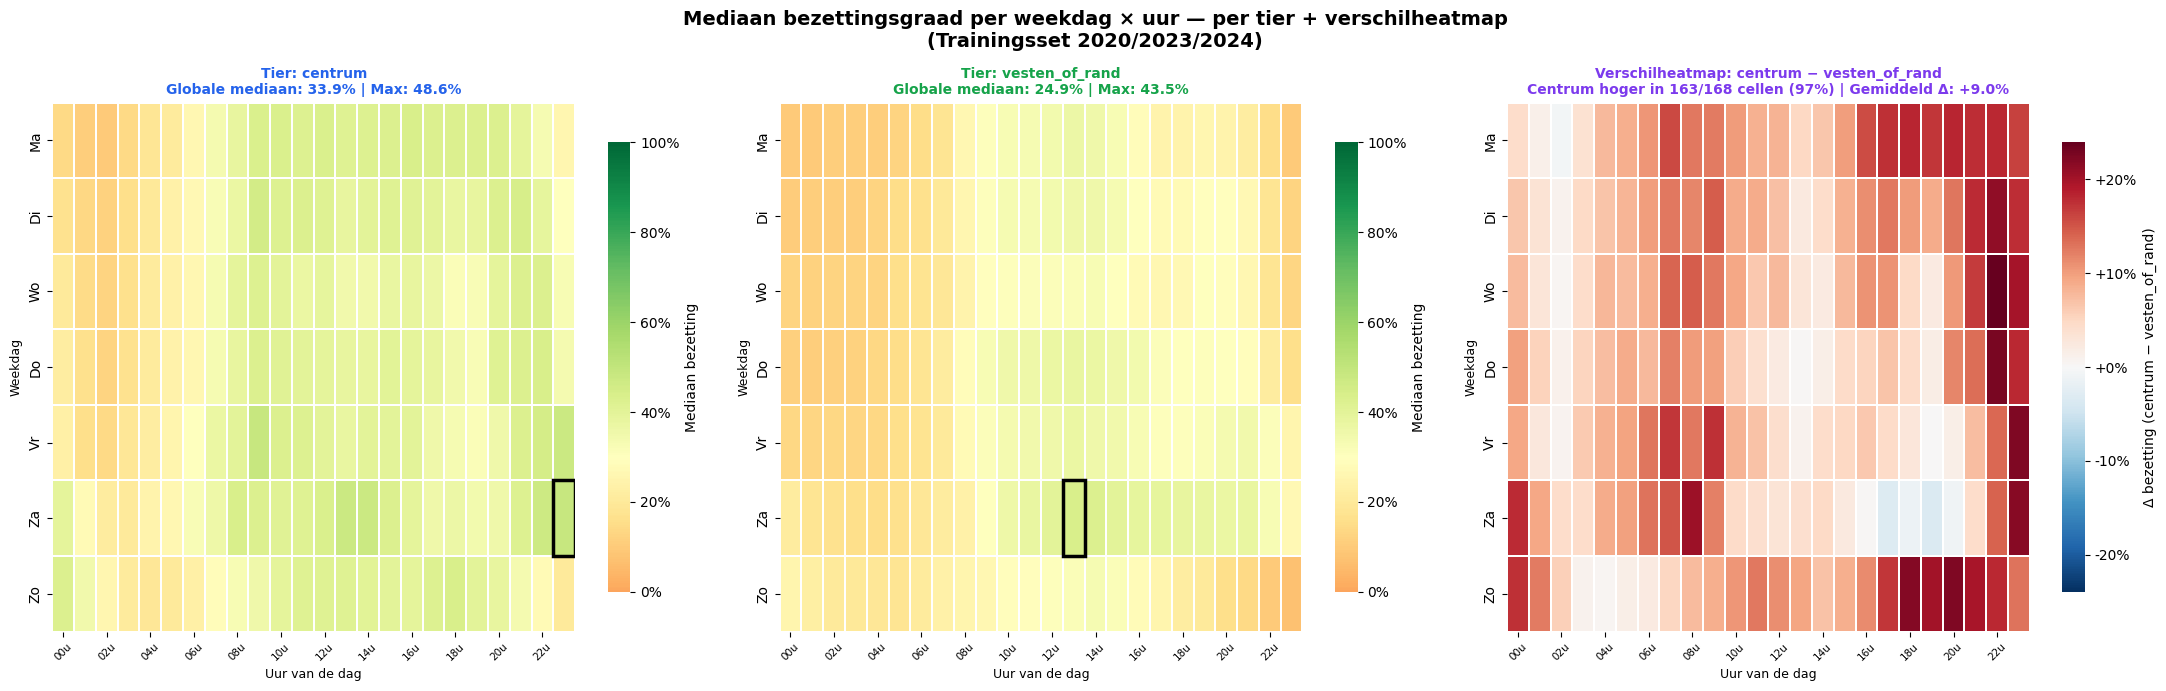

✓ Opgeslagen: fig_heatmap_tier_hour.png

── Verschilheatmap samenvatting ──
  Centrum hoger dan vesten_of_rand : 163/168 cellen (97.0%)
  Vesten_of_rand hoger             : 5/168 cellen (3.0%)
  Gemiddeld Δ (alle cellen)         : +9.0%
  Max Δ (centrum hoogst)            : +24.0% @ ('Wo', np.int32(22))
  Min Δ (vesten_of_rand hoogst)     : -3.5% @ ('Za', np.int32(19))


In [8]:
# ─── Cel 04: Heatmap tier × uur × weekdag ────────────────────────────────────
import seaborn as sns

WEEKDAY_LABELS = ["Ma", "Di", "Wo", "Do", "Vr", "Za", "Zo"]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "Mediaan bezettingsgraad per weekdag × uur — per tier + verschilheatmap\n"
    "(Trainingsset 2020/2023/2024)",
    fontsize=14, fontweight="bold"
)

pivots = {}
for tier in TIER_ORDER:
    pivot = (
        df_train[df_train["tier"] == tier]
        .groupby(["weekday_int", "hour"])["occupancy_rate"]
        .median()
        .unstack("hour")
    )
    pivot.index = [WEEKDAY_LABELS[i] for i in pivot.index]
    pivots[tier] = pivot

# ── Absolute heatmaps ─────────────────────────────────────────────────────────
global_min = min(p.values.min() for p in pivots.values())
global_max = max(p.values.max() for p in pivots.values())
global_med = df_train["occupancy_rate"].median()

for ax_idx, tier in enumerate(TIER_ORDER):
    ax = axes[ax_idx]
    pivot = pivots[tier]
    
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="RdYlGn",
        center=global_med,
        vmin=0, vmax=1,
        linewidths=0.3,
        linecolor="white",
        cbar_kws={
            "label": "Mediaan bezetting",
            "shrink": 0.85,
            "format": lambda x, _: f"{x:.0%}"
        },
        xticklabels=2
    )
    
    # Markeer piekcel
    peak_idx = pivot.stack().idxmax()
    peak_row  = list(pivot.index).index(peak_idx[0])
    peak_col  = list(pivot.columns).index(peak_idx[1])
    ax.add_patch(plt.Rectangle(
        (peak_col, peak_row), 1, 1,
        fill=False, edgecolor="black", lw=2.5, zorder=5
    ))
    
    ax.set_title(
        f"Tier: {tier}\n"
        f"Globale mediaan: {pivot.values.mean():.1%} | "
        f"Max: {pivot.stack().max():.1%}",
        fontsize=10, fontweight="bold", color=TIER_COLORS[tier]
    )
    ax.set_xlabel("Uur van de dag", fontsize=9)
    ax.set_ylabel("Weekdag", fontsize=9)
    ax.set_xticklabels(
        [f"{int(t.get_text()):02d}u" if t.get_text().isdigit() else t.get_text()
         for t in ax.get_xticklabels()],
        rotation=45, fontsize=7.5
    )

# ── Verschilheatmap (centrum - vesten_of_rand) ────────────────────────────────
ax_diff = axes[2]

# Zorg dat indices gelijk zijn
p_centrum = pivots["centrum"]
p_vestan  = pivots["vesten_of_rand"]
common_idx  = p_centrum.index.intersection(p_vestan.index)
common_cols = p_centrum.columns.intersection(p_vestan.columns)
diff_pivot  = p_centrum.loc[common_idx, common_cols] - p_vestan.loc[common_idx, common_cols]

abs_max = max(abs(diff_pivot.values.min()), abs(diff_pivot.values.max()))

sns.heatmap(
    diff_pivot,
    ax=ax_diff,
    cmap="RdBu_r",
    center=0,
    vmin=-abs_max, vmax=abs_max,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={
        "label": "Δ bezetting (centrum − vesten_of_rand)",
        "shrink": 0.85,
        "format": lambda x, _: f"{x:+.0%}"
    },
    xticklabels=2,
    annot=False
)

# Statistieken verschilheatmap
n_pos  = (diff_pivot > 0).values.sum()
n_neg  = (diff_pivot < 0).values.sum()
n_tot  = diff_pivot.size
pct_pos = n_pos / n_tot * 100

ax_diff.set_title(
    f"Verschilheatmap: centrum − vesten_of_rand\n"
    f"Centrum hoger in {n_pos}/{n_tot} cellen ({pct_pos:.0f}%) | "
    f"Gemiddeld Δ: {diff_pivot.values.mean():+.1%}",
    fontsize=10, fontweight="bold", color="#7C3AED"
)
ax_diff.set_xlabel("Uur van de dag", fontsize=9)
ax_diff.set_ylabel("Weekdag", fontsize=9)
ax_diff.set_xticklabels(
    [f"{int(t.get_text()):02d}u" if t.get_text().isdigit() else t.get_text()
     for t in ax_diff.get_xticklabels()],
    rotation=45, fontsize=7.5
)

plt.tight_layout()
plt.savefig(FIGS / "fig_heatmap_tier_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_heatmap_tier_hour.png")

print(f"\n── Verschilheatmap samenvatting ──")
print(f"  Centrum hoger dan vesten_of_rand : {n_pos}/{n_tot} cellen ({pct_pos:.1f}%)")
print(f"  Vesten_of_rand hoger             : {n_neg}/{n_tot} cellen ({100-pct_pos:.1f}%)")
print(f"  Gemiddeld Δ (alle cellen)         : {diff_pivot.values.mean():+.1%}")
print(f"  Max Δ (centrum hoogst)            : {diff_pivot.values.max():+.1%} "
      f"@ {diff_pivot.stack().idxmax()}")
print(f"  Min Δ (vesten_of_rand hoogst)     : {diff_pivot.values.min():+.1%} "
      f"@ {diff_pivot.stack().idxmin()}")


## Cel 05 — Scatter: capaciteit × gemiddelde bezetting
### Hypothese: H-S2 (Capaciteitsparadox)

> "Negatieve correlatie tussen `total_capacity` en `mean_occupancy_rate` —
> grotere parkings zijn relatief minder bezet."

**Theoretische basis:**
Wang & Li (2024) en Sun et al. (2023) beschrijven de **capaciteitsparadox**
in stedelijke parkeersystemen: grotere parkings trekken meer bezoekers
in absolute aantallen, maar hebben structureel lagere bezettingsgraden
omdat ze buffercapaciteit bieden. Bezoekers vermijden volle kleine parkings
en wijken uit naar grotere.

**Statistische toets — Spearman rangcorrelatie:**
We kiezen Spearman ρ boven Pearson r omdat:
1. N = 10 parkings → kleine steekproef, normaliteitsaanname niet toetsbaar
2. Het verwachte verband is mogelijk niet-lineair (exponentieel afnemend)
3. Spearman is robuuster voor uitschieters (P Keerdok: 516 pl.)

\[ \rho_s = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)} \]

waarbij \(d_i\) het verschil in rang is tussen capaciteit en bezetting
voor parking i (Spearman, 1904; Conover, 1999).

Interpretatie ρ: |ρ| < 0.3 = zwak, 0.3-0.7 = matig, > 0.7 = sterk.

**OLS-regressielijn** (visueel):
Een eenvoudige lineaire regressie \(\hat{y} = \beta_0 + \beta_1 x\)
wordt getoond als visueel hulpmiddel — NIET voor causale inferentie
(N=10 is te klein voor robuuste regressie). De regressielijn dient
enkel om de richting van het verband te illustreren.

**Uitsplitsing per tier:**
We plotten centrum en vesten_of_rand apart om te controleren of de
capaciteitsparadox uniform geldt, of tier-specifiek is.


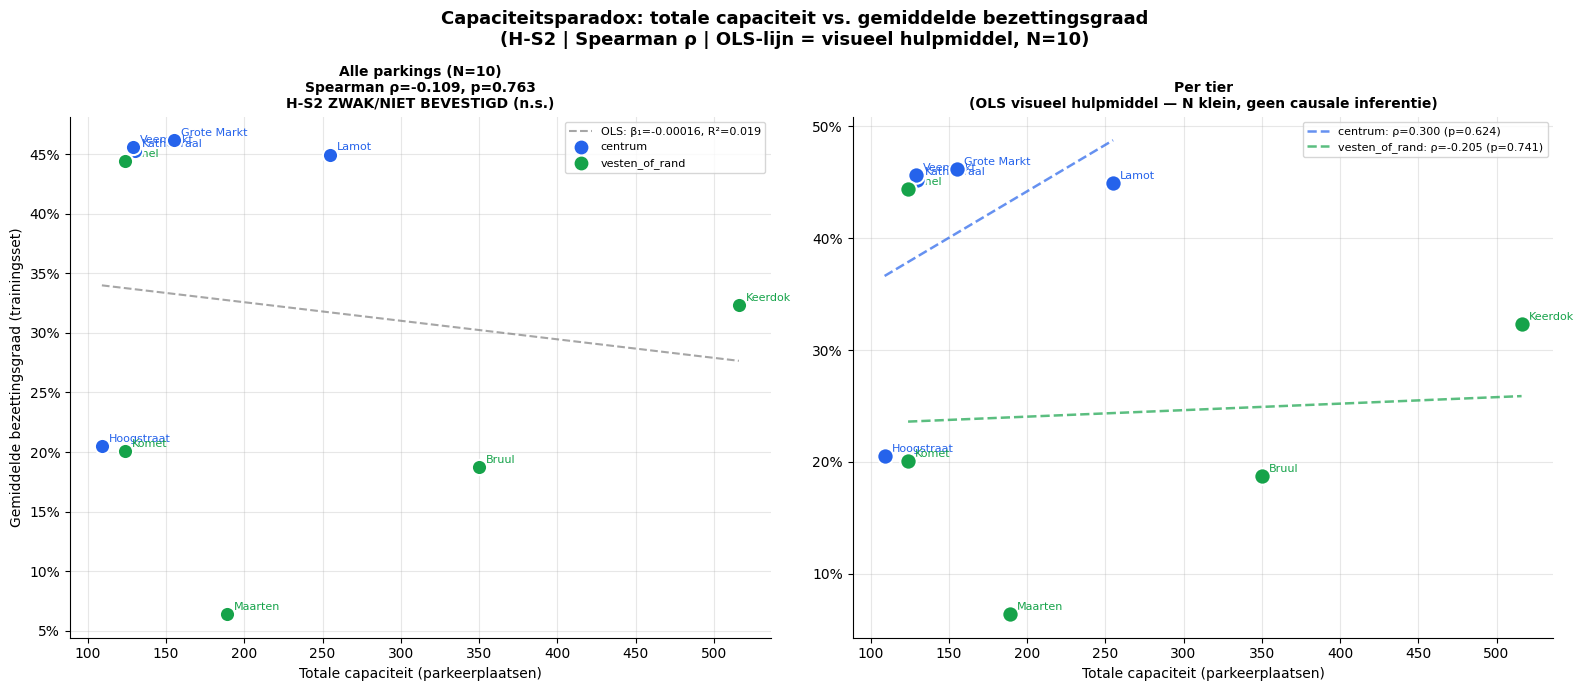

✓ Opgeslagen: fig_capacity_scatter.png

── Spearman-resultaten capaciteitsparadox ──
  Alle parkings : ρ=-0.1094, p=0.7635
  centrum              : ρ=0.3000, p=0.6238, N=5
  vesten_of_rand       : ρ=-0.2052, p=0.7406, N=5


In [9]:
# ─── Cel 05: Scatter capaciteit × gemiddelde bezetting ───────────────────────
from scipy.stats import spearmanr, pearsonr, linregress

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Capaciteitsparadox: totale capaciteit vs. gemiddelde bezettingsgraad\n"
    "(H-S2 | Spearman ρ | OLS-lijn = visueel hulpmiddel, N=10)",
    fontsize=13, fontweight="bold"
)

all_cap  = df_stats["capacity"].values.astype(float)
all_mean = df_stats["mean"].values.astype(float)

# ── Linker panel: alle parkings ───────────────────────────────────────────────
ax = axes[0]

for _, row in df_stats.iterrows():
    pid   = row["parking_id"]
    color = TIER_COLORS[row["tier"]]
    ax.scatter(row["capacity"], row["mean"],
               color=color, s=120, zorder=4, edgecolors="white", lw=1.5)
    ax.annotate(
        pid.replace("P ", ""),
        xy=(row["capacity"], row["mean"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=8, color=color
    )

# OLS-lijn alle parkings
valid = ~(np.isnan(all_cap) | np.isnan(all_mean))
if valid.sum() >= 3:
    slope, intercept, r_val, p_ols, se = linregress(all_cap[valid], all_mean[valid])
    x_line = np.linspace(all_cap[valid].min(), all_cap[valid].max(), 100)
    ax.plot(x_line, intercept + slope * x_line,
            color="gray", ls="--", lw=1.5, alpha=0.7,
            label=f"OLS: β₁={slope:.5f}, R²={r_val**2:.3f}")

# Spearman alle parkings
rho_all, p_rho_all = spearmanr(all_cap[valid], all_mean[valid])
ax.set_title(
    f"Alle parkings (N={valid.sum()})\n"
    f"Spearman ρ={rho_all:.3f}, p={p_rho_all:.3f}\n"
    f"{'H-S2 BEVESTIGD' if rho_all < -0.3 else 'H-S2 ZWAK/NIET BEVESTIGD'} "
    f"({'p<0.05' if p_rho_all < 0.05 else 'n.s.'})",
    fontsize=10, fontweight="bold"
)
ax.set_xlabel("Totale capaciteit (parkeerplaatsen)", fontsize=10)
ax.set_ylabel("Gemiddelde bezettingsgraad (trainingsset)", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Tier-legenda
for tier, color in TIER_COLORS.items():
    ax.scatter([], [], color=color, s=80, label=tier)
ax.legend(fontsize=8)

# ── Rechter panel: per tier (aparte regressielijnen) ─────────────────────────
ax2 = axes[1]

spearman_results = {}
for tier, color in TIER_COLORS.items():
    sub = df_stats[df_stats["tier"] == tier]
    cap_t  = sub["capacity"].values.astype(float)
    mean_t = sub["mean"].values.astype(float)
    
    for _, row in sub.iterrows():
        ax2.scatter(row["capacity"], row["mean"],
                    color=TIER_COLORS[row["tier"]], s=140,
                    zorder=4, edgecolors="white", lw=1.5)
        ax2.annotate(
            row["parking_id"].replace("P ", ""),
            xy=(row["capacity"], row["mean"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=8, color=TIER_COLORS[row["tier"]]
        )
    
    # Spearman per tier
    if len(cap_t) >= 3:
        rho_t, p_t = spearmanr(cap_t, mean_t)
        spearman_results[tier] = {"rho": rho_t, "p": p_t, "n": len(cap_t)}
        
        # OLS per tier
        if len(cap_t) >= 3:
            slope_t, intercept_t, r_t, _, _ = linregress(cap_t, mean_t)
            x_t = np.linspace(cap_t.min(), cap_t.max(), 50)
            ax2.plot(x_t, intercept_t + slope_t * x_t,
                     color=color, ls="--", lw=1.8, alpha=0.7,
                     label=f"{tier}: ρ={rho_t:.3f} (p={p_t:.3f})")
    elif len(cap_t) == 2:
        rho_t, p_t = np.nan, np.nan
        spearman_results[tier] = {"rho": rho_t, "p": p_t, "n": len(cap_t)}
        ax2.plot(cap_t, mean_t, color=color, ls="--", lw=1.8, alpha=0.6,
                 label=f"{tier}: N={len(cap_t)} (te klein voor Spearman)")

ax2.set_title(
    "Per tier\n(OLS visueel hulpmiddel — N klein, geen causale inferentie)",
    fontsize=10, fontweight="bold"
)
ax2.set_xlabel("Totale capaciteit (parkeerplaatsen)", fontsize=10)
ax2.set_ylabel("", fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_capacity_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_capacity_scatter.png")

print("\n── Spearman-resultaten capaciteitsparadox ──")
print(f"  Alle parkings : ρ={rho_all:.4f}, p={p_rho_all:.4f}")
for tier, res in spearman_results.items():
    print(f"  {tier:20s} : ρ={res['rho']:.4f}, p={res['p']:.4f}, N={res['n']}")


## Cel 06 — Pearson correlatiematrix (10 × 10 parkings)
### Hypothese: H-S3

> "Parkings binnen dezelfde tier zijn sterker gecorreleerd (r > 0.6) dan
> parkings uit verschillende tiers (r < 0.4) →
> verantwoordt tier als modelleringsstratificatie."

**Statistische aanpak:**
Pearson-correlatie \(r\) op uurlijkse bezetting per parking, berekend
op de gedeelde observaties (tijdstempels aanwezig in beide parkings):

\[ r(X, Y) = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}} \]

Keuze Pearson boven Spearman: we testen lineaire samenhang in het
bezettingsniveau — niet rangcorrelatie. De data is uurlijks geaggregeerd
per parking (gemiddelde over alle waarnemingen dat uur), wat voldoende
normaliteit benadert via de CLT (Casella & Berger, 2002).

**Fischer z-toets (intra- vs. inter-tier):**
Om te testen of intra-tier correlaties significant hoger zijn dan
inter-tier correlaties, gebruiken we de **Fischer z-transformatie**:
\[ z = \frac{1}{2} \ln\left(\frac{1+r}{1-r}\right) \]
en toetsen het verschil tussen de gemiddelde intra-tier z en de
gemiddelde inter-tier z (Fischer, 1921; Cohen et al., 2003).

**Pivot-constructie:**
We aggregeren naar uurlijkse bezetting per parking per tijdstempel
(`rounded_hour`), dan wide-format via pivot. Alleen tijdstempels
aanwezig in ≥8 van de 10 parkings worden gebruikt om selectiebias
te vermijden (missingness-drempel).

**Clusterordening:**
De heatmap wordt geordend via hiërarchisch clusteren (Ward-methode,
Euclidische afstand op de correlatiematrix). Als H-S3 klopt, zouden
de clusters de tier-structuur recapituleren.


Pivot shape na missingness-filter (≥8/10 parkings): (3263, 10)
Gemiddelde tijdsdekking per parking:
parking_id
P Bruul          1.000
P Grote Markt    1.000
P Hoogstraat     1.000
P Kathedraal     1.000
P Keerdok        1.000
P Komet          0.928
P Lamot          1.000
P Maarten        0.928
P Tinel          1.000
P Veemarkt       1.000


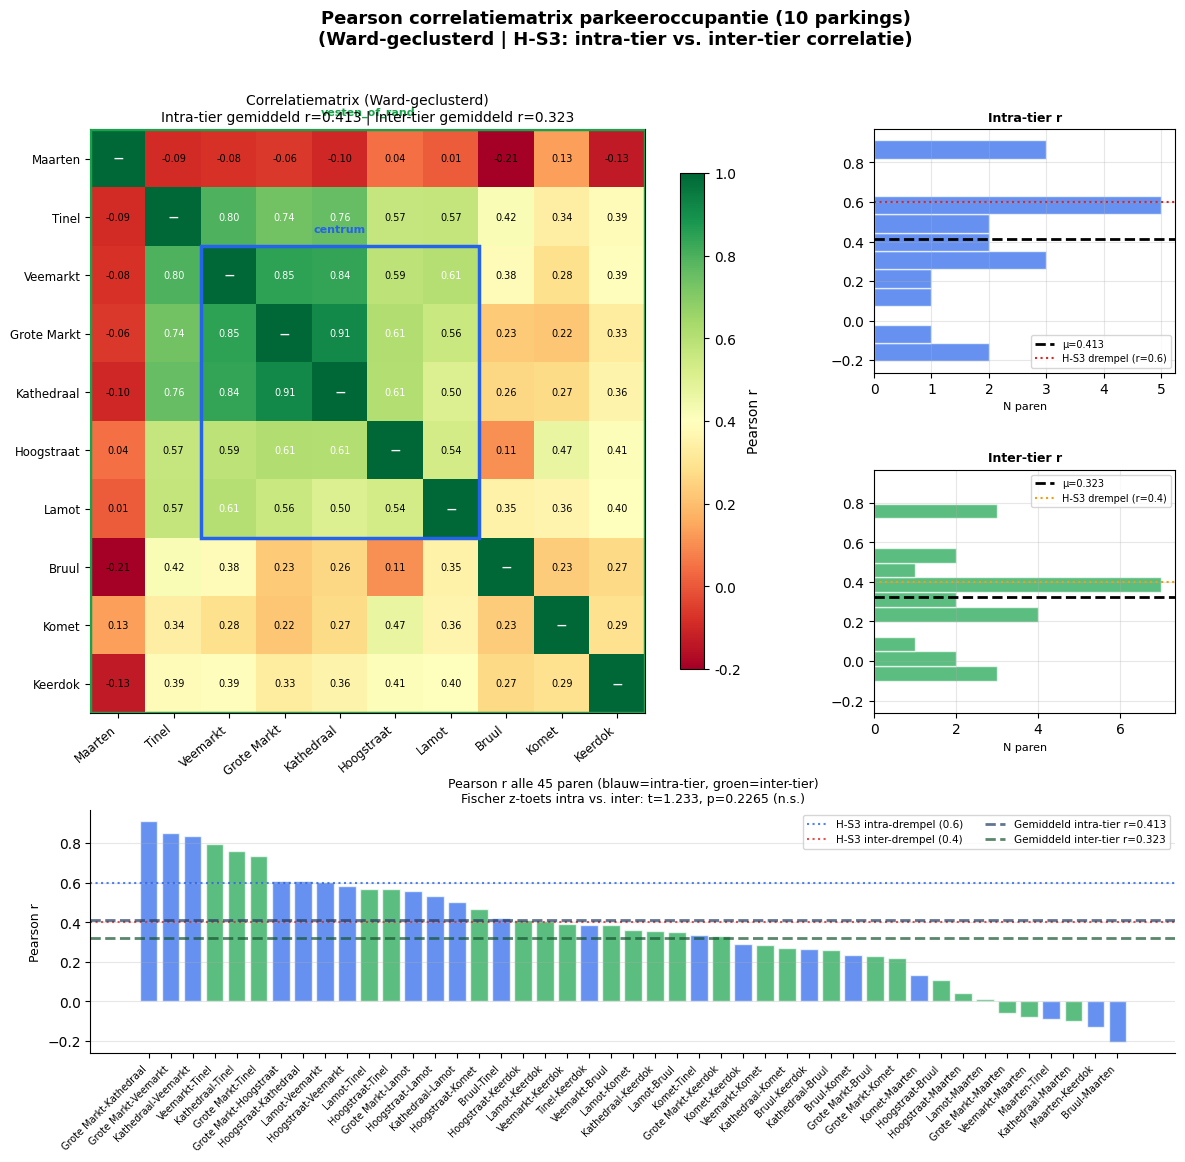

✓ Opgeslagen: fig_corr_matrix.png

── H-S3 samenvatting ──
  Gemiddelde intra-tier r : 0.4126 (≤ 0.6 ❌)
  Gemiddelde inter-tier r : 0.3232 (< 0.4 ✅)
  Fischer z-toets         : t=1.2326, p=0.2265
  H-S3 conclusie          : GEDEELTELIJK/VERWORPEN


In [10]:
# ─── Cel 06: Pearson correlatiematrix 10 × 10 parkings ───────────────────────
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import norm as scipy_norm

# ── Pivot: uurlijkse bezetting per parking ─────────────────────────────────
pivot_wide = (
    df_train
    .groupby(["rounded_hour", "parking_id"])["occupancy_rate"]
    .mean()
    .unstack("parking_id")
)

# Bewaar alleen tijdstempels met ≥8 van de 10 parkings aanwezig
coverage_mask = pivot_wide.notna().sum(axis=1) >= 8
pivot_wide    = pivot_wide[coverage_mask]

print(f"Pivot shape na missingness-filter (≥8/10 parkings): {pivot_wide.shape}")
print(f"Gemiddelde tijdsdekking per parking:")
print(pivot_wide.notna().mean().round(3).to_string())

# ── Pearson correlatiematrix ──────────────────────────────────────────────────
available_parkings = [p for p in PARKING_ORDER if p in pivot_wide.columns]
corr_matrix = pivot_wide[available_parkings].corr(method="pearson")

# ── Hiërarchisch clusteren (Ward) op 1 - r ───────────────────────────────────
dist_matrix    = 1 - corr_matrix.values
dist_matrix    = np.clip(dist_matrix, 0, 2)
condensed_dist = squareform(dist_matrix, checks=False)
linkage_matrix  = linkage(condensed_dist, method="ward")
cluster_order   = leaves_list(linkage_matrix)
ordered_parkings = [available_parkings[i] for i in cluster_order]

# ── Intra- vs. inter-tier correlaties ────────────────────────────────────────
intra_r = []
inter_r = []

for i, p1 in enumerate(available_parkings):
    for j, p2 in enumerate(available_parkings):
        if j <= i:
            continue
        r_val = corr_matrix.loc[p1, p2]
        t1 = PARKING_TIER_MAP.get(p1)
        t2 = PARKING_TIER_MAP.get(p2)
        if t1 == t2:
            intra_r.append(r_val)
        else:
            inter_r.append(r_val)

mean_intra = np.mean(intra_r)
mean_inter = np.mean(inter_r)

# Fischer z-toets
def fisher_z(r):
    r = np.clip(r, -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

z_intra = [fisher_z(r) for r in intra_r]
z_inter = [fisher_z(r) for r in inter_r]

# Two-sample t-test op z-scores
from scipy.stats import ttest_ind
t_stat, p_fisher = ttest_ind(z_intra, z_inter, equal_var=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)
ax_heatmap  = fig.add_subplot(gs[:2, :2])
ax_intra    = fig.add_subplot(gs[0, 2])
ax_inter    = fig.add_subplot(gs[1, 2], sharey=ax_intra)
ax_bar      = fig.add_subplot(gs[2, :])

fig.suptitle(
    "Pearson correlatiematrix parkeeroccupantie (10 parkings)\n"
    "(Ward-geclusterd | H-S3: intra-tier vs. inter-tier correlatie)",
    fontsize=13, fontweight="bold"
)

# Heatmap
corr_ordered = corr_matrix.loc[ordered_parkings, ordered_parkings]
mask_diag    = np.eye(len(ordered_parkings), dtype=bool)

# Tier-kleurband
tier_colors_band = [TIER_COLORS[PARKING_TIER_MAP.get(p, "vesten_of_rand")]
                    for p in ordered_parkings]

im = ax_heatmap.imshow(
    corr_ordered.values,
    cmap="RdYlGn", vmin=-0.2, vmax=1.0, aspect="auto"
)
plt.colorbar(im, ax=ax_heatmap, shrink=0.85,
             label="Pearson r", format=lambda x, _: f"{x:.1f}")

# Grid + labels
n = len(ordered_parkings)
ax_heatmap.set_xticks(range(n))
ax_heatmap.set_yticks(range(n))
ax_heatmap.set_xticklabels(
    [p.replace("P ", "") for p in ordered_parkings],
    rotation=40, ha="right", fontsize=8.5
)
ax_heatmap.set_yticklabels(
    [p.replace("P ", "") for p in ordered_parkings], fontsize=8.5
)

# Annoteer met r-waarden
for i in range(n):
    for j in range(n):
        val = corr_ordered.iloc[i, j]
        txt = f"{val:.2f}" if i != j else "—"
        color = "white" if abs(val) > 0.6 else "black"
        ax_heatmap.text(j, i, txt, ha="center", va="center",
                        fontsize=7, color=color, fontweight="bold" if i == j else "normal")

# Tier-grenslijnen tekenen
tier_groups = {}
for i, p in enumerate(ordered_parkings):
    t = PARKING_TIER_MAP.get(p)
    tier_groups.setdefault(t, []).append(i)

for tier_name, idxs in tier_groups.items():
    lo, hi = min(idxs), max(idxs)
    rect = plt.Rectangle(
        (lo - 0.5, lo - 0.5), hi - lo + 1, hi - lo + 1,
        fill=False, edgecolor=TIER_COLORS.get(tier_name, "gray"),
        lw=2.5, zorder=5
    )
    ax_heatmap.add_patch(rect)
    ax_heatmap.text(
        (lo + hi) / 2, lo - 0.7,
        tier_name, ha="center", va="bottom", fontsize=8,
        fontweight="bold", color=TIER_COLORS.get(tier_name, "gray")
    )

ax_heatmap.set_title(
    f"Correlatiematrix (Ward-geclusterd)\n"
    f"Intra-tier gemiddeld r={mean_intra:.3f} | "
    f"Inter-tier gemiddeld r={mean_inter:.3f}",
    fontsize=10
)

# Distributie intra-tier correlaties
ax_intra.hist(intra_r, bins=12, color=TIER_COLORS["centrum"], alpha=0.7,
              edgecolor="white", orientation="horizontal")
ax_intra.axhline(mean_intra, color="black", lw=2, ls="--",
                 label=f"μ={mean_intra:.3f}")
ax_intra.axhline(0.6, color="#DC2626", lw=1.5, ls=":",
                 label="H-S3 drempel (r=0.6)")
ax_intra.set_title("Intra-tier r", fontsize=9, fontweight="bold")
ax_intra.set_xlabel("N paren", fontsize=8)
ax_intra.legend(fontsize=7)
ax_intra.grid(alpha=0.3)

# Distributie inter-tier correlaties
ax_inter.hist(inter_r, bins=12, color=TIER_COLORS["vesten_of_rand"], alpha=0.7,
              edgecolor="white", orientation="horizontal")
ax_inter.axhline(mean_inter, color="black", lw=2, ls="--",
                 label=f"μ={mean_inter:.3f}")
ax_inter.axhline(0.4, color="#F59E0B", lw=1.5, ls=":",
                 label="H-S3 drempel (r=0.4)")
ax_inter.set_title("Inter-tier r", fontsize=9, fontweight="bold")
ax_inter.set_xlabel("N paren", fontsize=8)
ax_inter.legend(fontsize=7)
ax_inter.grid(alpha=0.3)

# Bar chart: gemiddelde r per parkingpaar
pair_data = []
for i, p1 in enumerate(available_parkings):
    for j, p2 in enumerate(available_parkings):
        if j <= i:
            continue
        pair_data.append({
            "pair":     f"{p1.replace('P ','')}-{p2.replace('P ','')}",
            "r":        corr_matrix.loc[p1, p2],
            "type":     "intra" if PARKING_TIER_MAP.get(p1) == PARKING_TIER_MAP.get(p2)
                        else "inter",
        })
df_pairs = pd.DataFrame(pair_data).sort_values("r", ascending=False)

colors_bar = [TIER_COLORS["centrum"] if t == "intra" else TIER_COLORS["vesten_of_rand"]
              for t in df_pairs["type"]]
ax_bar.bar(range(len(df_pairs)), df_pairs["r"].values,
           color=colors_bar, alpha=0.7, edgecolor="white", width=0.8)
ax_bar.axhline(0.6, color="#2563EB", lw=1.5, ls=":", alpha=0.8, label="H-S3 intra-drempel (0.6)")
ax_bar.axhline(0.4, color="#DC2626", lw=1.5, ls=":", alpha=0.8, label="H-S3 inter-drempel (0.4)")
ax_bar.axhline(mean_intra, color="#1E3A5F", lw=2, ls="--", alpha=0.7,
               label=f"Gemiddeld intra-tier r={mean_intra:.3f}")
ax_bar.axhline(mean_inter, color="#14532D", lw=2, ls="--", alpha=0.7,
               label=f"Gemiddeld inter-tier r={mean_inter:.3f}")
ax_bar.set_xticks(range(len(df_pairs)))
ax_bar.set_xticklabels(df_pairs["pair"].values, rotation=45, ha="right", fontsize=7)
ax_bar.set_ylabel("Pearson r", fontsize=9)
ax_bar.set_title(
    f"Pearson r alle {len(df_pairs)} paren (blauw=intra-tier, groen=inter-tier)\n"
    f"Fischer z-toets intra vs. inter: t={t_stat:.3f}, p={p_fisher:.4f} "
    f"({'significant' if p_fisher < 0.05 else 'n.s.'})",
    fontsize=9
)
ax_bar.legend(fontsize=7.5, ncol=2)
ax_bar.grid(axis="y", alpha=0.3)
ax_bar.spines[["top", "right"]].set_visible(False)

plt.savefig(FIGS / "fig_corr_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_corr_matrix.png")

print(f"\n── H-S3 samenvatting ──")
print(f"  Gemiddelde intra-tier r : {mean_intra:.4f} "
      f"({'> 0.6 ✅' if mean_intra > 0.6 else '≤ 0.6 ❌'})")
print(f"  Gemiddelde inter-tier r : {mean_inter:.4f} "
      f"({'< 0.4 ✅' if mean_inter < 0.4 else '≥ 0.4 ❌'})")
print(f"  Fischer z-toets         : t={t_stat:.4f}, p={p_fisher:.4f}")
print(f"  H-S3 conclusie          : "
      f"{'BEVESTIGD' if mean_intra > 0.6 and mean_inter < 0.4 and p_fisher < 0.05 else 'GEDEELTELIJK/VERWORPEN'}")


## Cel 07 — Shortterm vs. Longterm vergelijking (2024, 7 parkings)
### Diagnostische analyse (geen hypothesetoets)

**Context:**
De MAD bevat zowel `shortterm` (betalende kortparkeerders) als
`longterm` (abonnees/seizoenhouders) bezettingsdata.
7 van de 10 parkings hebben beide datatypes in 2024.

**Vraag:** Hoe verhouden shortterm en longterm bezetting zich tot elkaar?
Is er complementariteit (als short vol is, is long leeg)?
Of corrigeren ze dezelfde ruimte (overlappende capaciteit)?

**Relevantie voor modellering:**
Als shortterm en longterm systematisch correleren → dan is de
gecombineerde bezetting een betere voorspellingsdoelvariabele.
Als ze complementair zijn → dan zijn aparte modellen per type zinvoller.

**Statistische aanpak:**
- Pearson correlatie shortterm vs. longterm per parking (uurlijks)
- Bland-Altman plot: systematisch verschil (bias) + limieten van
  overeenstemming (±1.96 SD van het verschil)
  Referentie: Bland & Altman (1986) — standaard voor methodenvergelijking

**Bland-Altman formules:**
\[ \text{Bias} = \bar{d} = \frac{1}{n}\sum(ST_i - LT_i) \]
\[ \text{LoA} = \bar{d} \pm 1.96 \cdot s_d \]

Een grote bias duidt op systematisch verschil in bezettingsniveau
tussen korte en lange termijn gebruik. Brede LoA wijzen op hoge
variabiliteit in het verschil — relevant voor modelonzekerheid.


Parkings met beide datatypes (2024): 7
  ['P Grote Markt', 'P Hoogstraat', 'P Kathedraal', 'P Komet', 'P Maarten', 'P Tinel', 'P Keerdok']

── Shortterm vs. Longterm vergelijking ──
   parking_id           tier  n_hours  mean_st  mean_lt  pearson_r  pearson_p  ba_bias  ba_loa_lo  ba_loa_hi
P Grote Markt        centrum     6478   0.4356   0.3410     0.5500     0.0000   0.0946    -0.4804     0.6695
 P Hoogstraat        centrum     7805   0.2535   0.7150    -0.0559     0.0000  -0.4615    -0.9928     0.0697
 P Kathedraal        centrum     6748   0.4435   0.3723     0.4339     0.0000   0.0712    -0.5466     0.6889
      P Komet vesten_of_rand     3053   0.2027   0.6976     0.2351     0.0000  -0.4949    -1.0199     0.0301
    P Maarten vesten_of_rand     5888   0.0636   0.1909     0.0412     0.0016  -0.1273    -0.3505     0.0960
      P Tinel vesten_of_rand      275   0.2046   0.5543     0.3887     0.0000  -0.3497    -0.9804     0.2809
    P Keerdok vesten_of_rand     8750   0.2857   0.2843

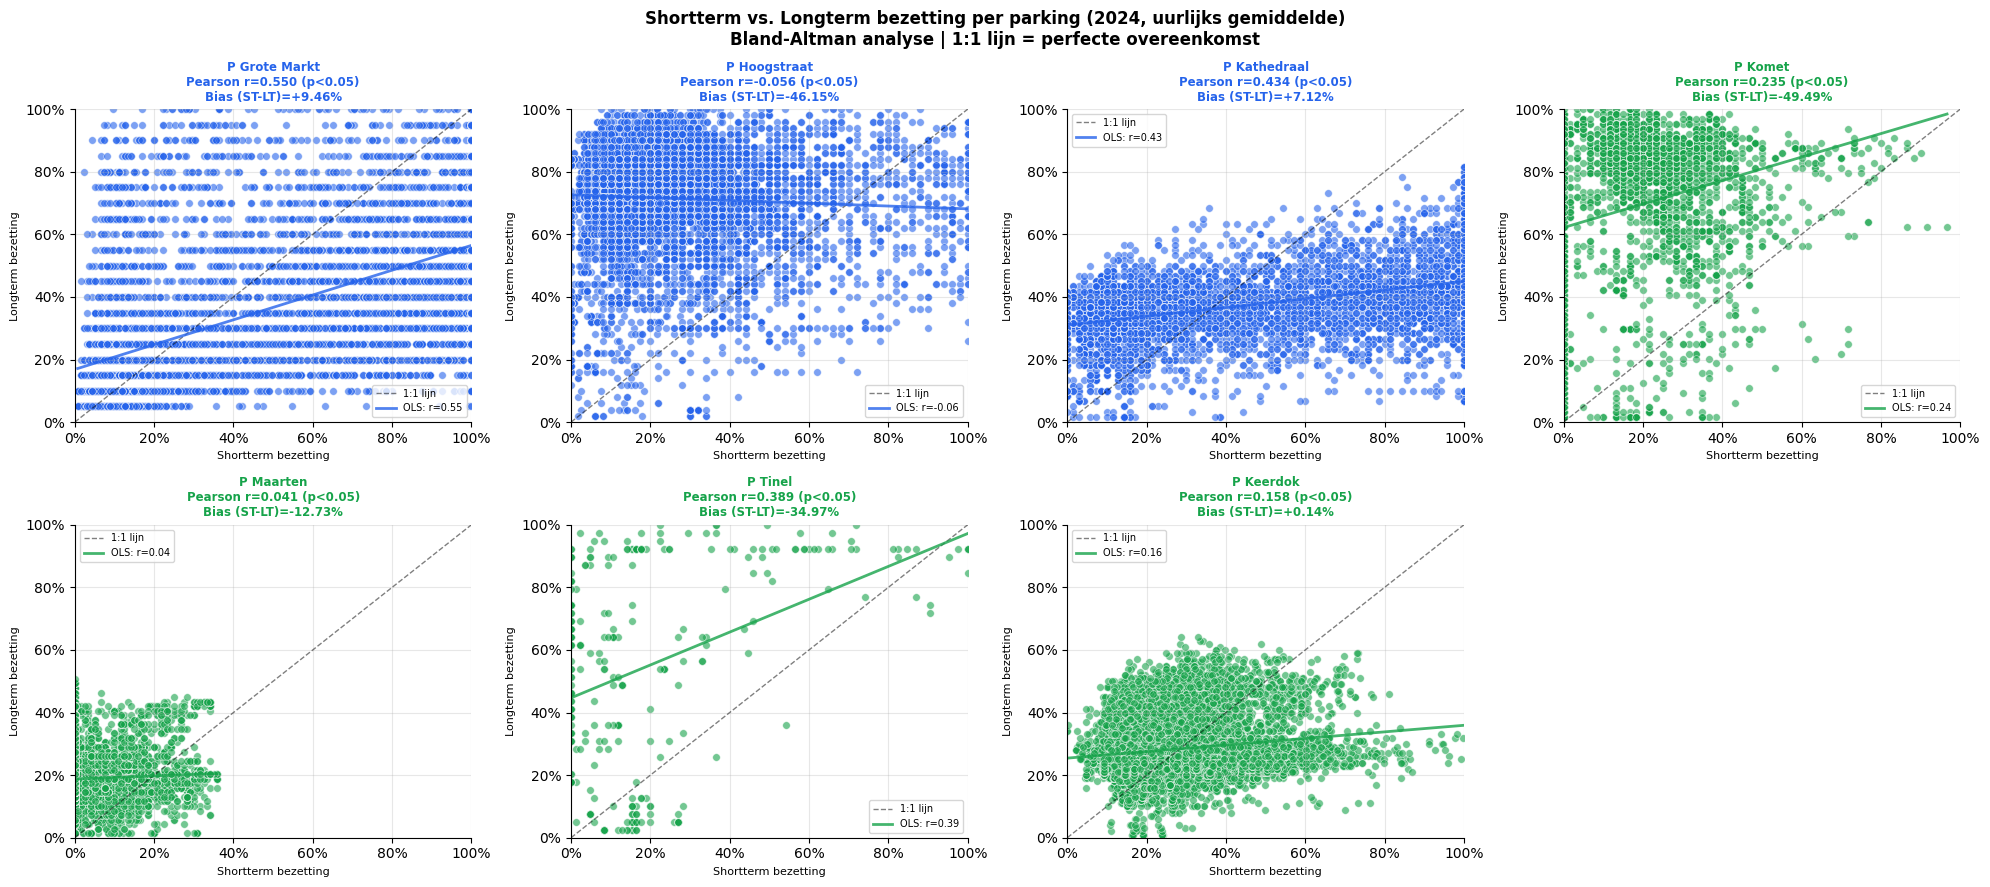

✓ Opgeslagen: fig_st_lt_comparison.png
✓ Opgeslagen: tabel_st_lt_comparison.csv


In [11]:
# ─── Cel 07: Shortterm vs. Longterm vergelijking (2024, 7 parkings) ──────────

# ── Longterm trainingsfilter ──────────────────────────────────────────────────
df_long_train = df_long[get_train_mask(df_long)].copy()
df_long_train["tier"] = (
    df_long_train["parking_location_category"]
    .astype(str)
    .replace({"rand": "vesten_of_rand", "vesten": "vesten_of_rand"})
)

# ── Alleen 2024 voor directe vergelijking ─────────────────────────────────────
st_2024 = df_train[df_train["year"] == 2024].copy()
lt_2024 = df_long_train[df_long_train["year"] == 2024].copy()

# Gemeenschappelijke parkings
common_parks = set(st_2024["parking_id"].unique()) & set(lt_2024["parking_id"].unique())
common_parks = [p for p in PARKING_ORDER if p in common_parks]
print(f"Parkings met beide datatypes (2024): {len(common_parks)}")
print(f"  {common_parks}")

# ── Uurlijkse vergelijking per parking ───────────────────────────────────────
comparison_rows = []
for pid in common_parks:
    st_occ = (
        st_2024[st_2024["parking_id"] == pid]
        .groupby("rounded_hour")["occupancy_rate"]
        .mean()
        .rename("shortterm")
    )
    lt_occ = (
        lt_2024[lt_2024["parking_id"] == pid]
        .groupby("rounded_hour")["occupancy_rate"]
        .mean()
        .rename("longterm")
    )
    merged = pd.concat([st_occ, lt_occ], axis=1).dropna()
    
    if len(merged) < 10:
        continue
    
    r_val, p_val = pearsonr(merged["shortterm"], merged["longterm"])
    diff         = merged["shortterm"] - merged["longterm"]
    mean_val     = (merged["shortterm"] + merged["longterm"]) / 2
    bias         = diff.mean()
    loa_lo       = bias - 1.96 * diff.std()
    loa_hi       = bias + 1.96 * diff.std()
    
    comparison_rows.append({
        "parking_id": pid,
        "tier":       PARKING_TIER_MAP.get(pid),
        "n_hours":    len(merged),
        "mean_st":    round(merged["shortterm"].mean(), 4),
        "mean_lt":    round(merged["longterm"].mean(), 4),
        "pearson_r":  round(r_val, 4),
        "pearson_p":  round(p_val, 4),
        "ba_bias":    round(bias, 4),
        "ba_loa_lo":  round(loa_lo, 4),
        "ba_loa_hi":  round(loa_hi, 4),
    })

df_comparison = pd.DataFrame(comparison_rows)
print("\n── Shortterm vs. Longterm vergelijking ──")
print(df_comparison.to_string(index=False))

# ── Visualisatie ─────────────────────────────────────────────────────────────
n_plots = len(common_parks)
n_cols  = min(4, n_plots)
n_rows  = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten() if n_plots > 1 else [axes]

fig.suptitle(
    "Shortterm vs. Longterm bezetting per parking (2024, uurlijks gemiddelde)\n"
    "Bland-Altman analyse | 1:1 lijn = perfecte overeenkomst",
    fontsize=12, fontweight="bold"
)

for ax_idx, pid in enumerate(common_parks):
    ax = axes[ax_idx]
    st_occ = (
        st_2024[st_2024["parking_id"] == pid]
        .groupby("rounded_hour")["occupancy_rate"].mean()
        .rename("shortterm")
    )
    lt_occ = (
        lt_2024[lt_2024["parking_id"] == pid]
        .groupby("rounded_hour")["occupancy_rate"].mean()
        .rename("longterm")
    )
    merged = pd.concat([st_occ, lt_occ], axis=1).dropna()
    
    if len(merged) < 3:
        ax.set_visible(False)
        continue
    
    row = df_comparison[df_comparison["parking_id"] == pid].iloc[0]
    color = TIER_COLORS[PARKING_TIER_MAP.get(pid, "vesten_of_rand")]
    
    ax.scatter(merged["shortterm"], merged["longterm"],
               color=color, alpha=0.6, s=30, edgecolors="white", lw=0.5)
    
    # 1:1 lijn
    lim = [0, 1]
    ax.plot(lim, lim, "k--", lw=1, alpha=0.5, label="1:1 lijn")
    
    # OLS
    slope, intercept, r_val2, _, _ = linregress(
        merged["shortterm"], merged["longterm"]
    )
    x_ols = np.linspace(merged["shortterm"].min(), merged["shortterm"].max(), 50)
    ax.plot(x_ols, intercept + slope * x_ols,
            color=color, lw=2, alpha=0.8,
            label=f"OLS: r={row['pearson_r']:.2f}")
    
    ax.set_title(
        f"{pid}\nPearson r={row['pearson_r']:.3f} "
        f"({'p<0.05' if row['pearson_p'] < 0.05 else 'n.s.'})\n"
        f"Bias (ST-LT)={row['ba_bias']:+.2%}",
        fontsize=8.5, color=color, fontweight="bold"
    )
    ax.set_xlabel("Shortterm bezetting", fontsize=8)
    ax.set_ylabel("Longterm bezetting", fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

# Verberg lege subplots
for i in range(len(common_parks), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / "fig_st_lt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_st_lt_comparison.png")

df_comparison.to_csv(FIGS / "tabel_st_lt_comparison.csv", index=False)
print("✓ Opgeslagen: tabel_st_lt_comparison.csv")


## Cel 08 — Tier-eventrespons: event vs. niet-event per tier
### Hypothese: H-S4 — KERNHYPOTHESE THESIS

> "Het bezettingseffect van externe events is **significant groter voor
> centrumparkings** dan voor vesten_of_rand —
> empirische basis voor tier-gestratificeerde SHAP-analyse in nb12."

**Belang voor de thesis:**
H-S4 is de meest originele bijdrage van deze masterproef. Geen enkele
studie heeft dit getest voor mid-sized Europese steden. Als bevestigd,
rechtvaardigt het zowel de tier-stratificatie in modellering (nb10)
als de 2-level SHAP-analyse (nb12).

**Statistische toets — Mann-Whitney U (per tier):**
Vergelijkt bezetting op event-uren vs. niet-event-uren:
- H₀: De mediaan bezetting op event-uren = mediaan op niet-event-uren
- H₁: De mediaan bezetting op event-uren > mediaan op niet-event-uren
- Eenzijdige toets (verwacht effect = positief): Fokker et al. (2021)

**Effect size — rank-biseriale correlatie r_rb:**
\[ r_{rb} = \frac{2U}{n_1 \cdot n_2} - 1 \]
waarbij U de Mann-Whitney statistiek is.
Interpretatie: |r| < 0.1 = verwaarloosbaar, 0.1-0.3 = klein,
0.3-0.5 = medium, > 0.5 = groot (Field, 2013).

**Verschiltoets tussen tiers — Fischer z op r_rb:**
Nadat we r_rb per tier berekend hebben, toetsen we of r_rb(centrum)
significant hoger is dan r_rb(vesten_of_rand) via de Fischer z-transformatie
op de effect sizes. Dit is de definitieve toets van H-S4.

**Controlevariabelen:**
We analyseren het eventeffect uitsluitend op **weekdagen** (day_type_3='weekday')
om confounding door weekendeffecten te vermijden. Events op weekenden
trekken sowieso meer bezoekers ongeacht tier.

**Event-uitsplitsing:**
Naast het overall eventeffect analyseren we elk event-type apart
(football, festival, procession, kermis, carnival) om te testen of
het tier-effect event-type-specifiek is.
Referentie: Fokker et al. (2021); Channamallu et al. (2024).


── H-S4: Effect size per tier per event-type ──
event_label           tier  n_event  mean_event  mean_non_event  delta_mean     mw_p    r_rb    effect_label  significant
Alle events        centrum     5014      0.4356          0.4043      0.0313 0.000000  0.0564 verwaarloosbaar         True
Alle events vesten_of_rand     4739      0.3193          0.2941      0.0251 0.000000  0.0632 verwaarloosbaar         True
    Voetbal        centrum      451      0.3312          0.4081     -0.0769 1.000000 -0.1667           klein        False
    Voetbal vesten_of_rand      320      0.3770          0.2965      0.0805 0.000000  0.2074           klein         True
   Festival        centrum       76      0.2302          0.4077     -0.1775 1.000000 -0.3866          medium        False
   Festival vesten_of_rand      190      0.2612          0.2973     -0.0362 0.966928 -0.0771 verwaarloosbaar        False
     Kermis        centrum     4069      0.4594          0.4029      0.0565 0.000000  0.1079      

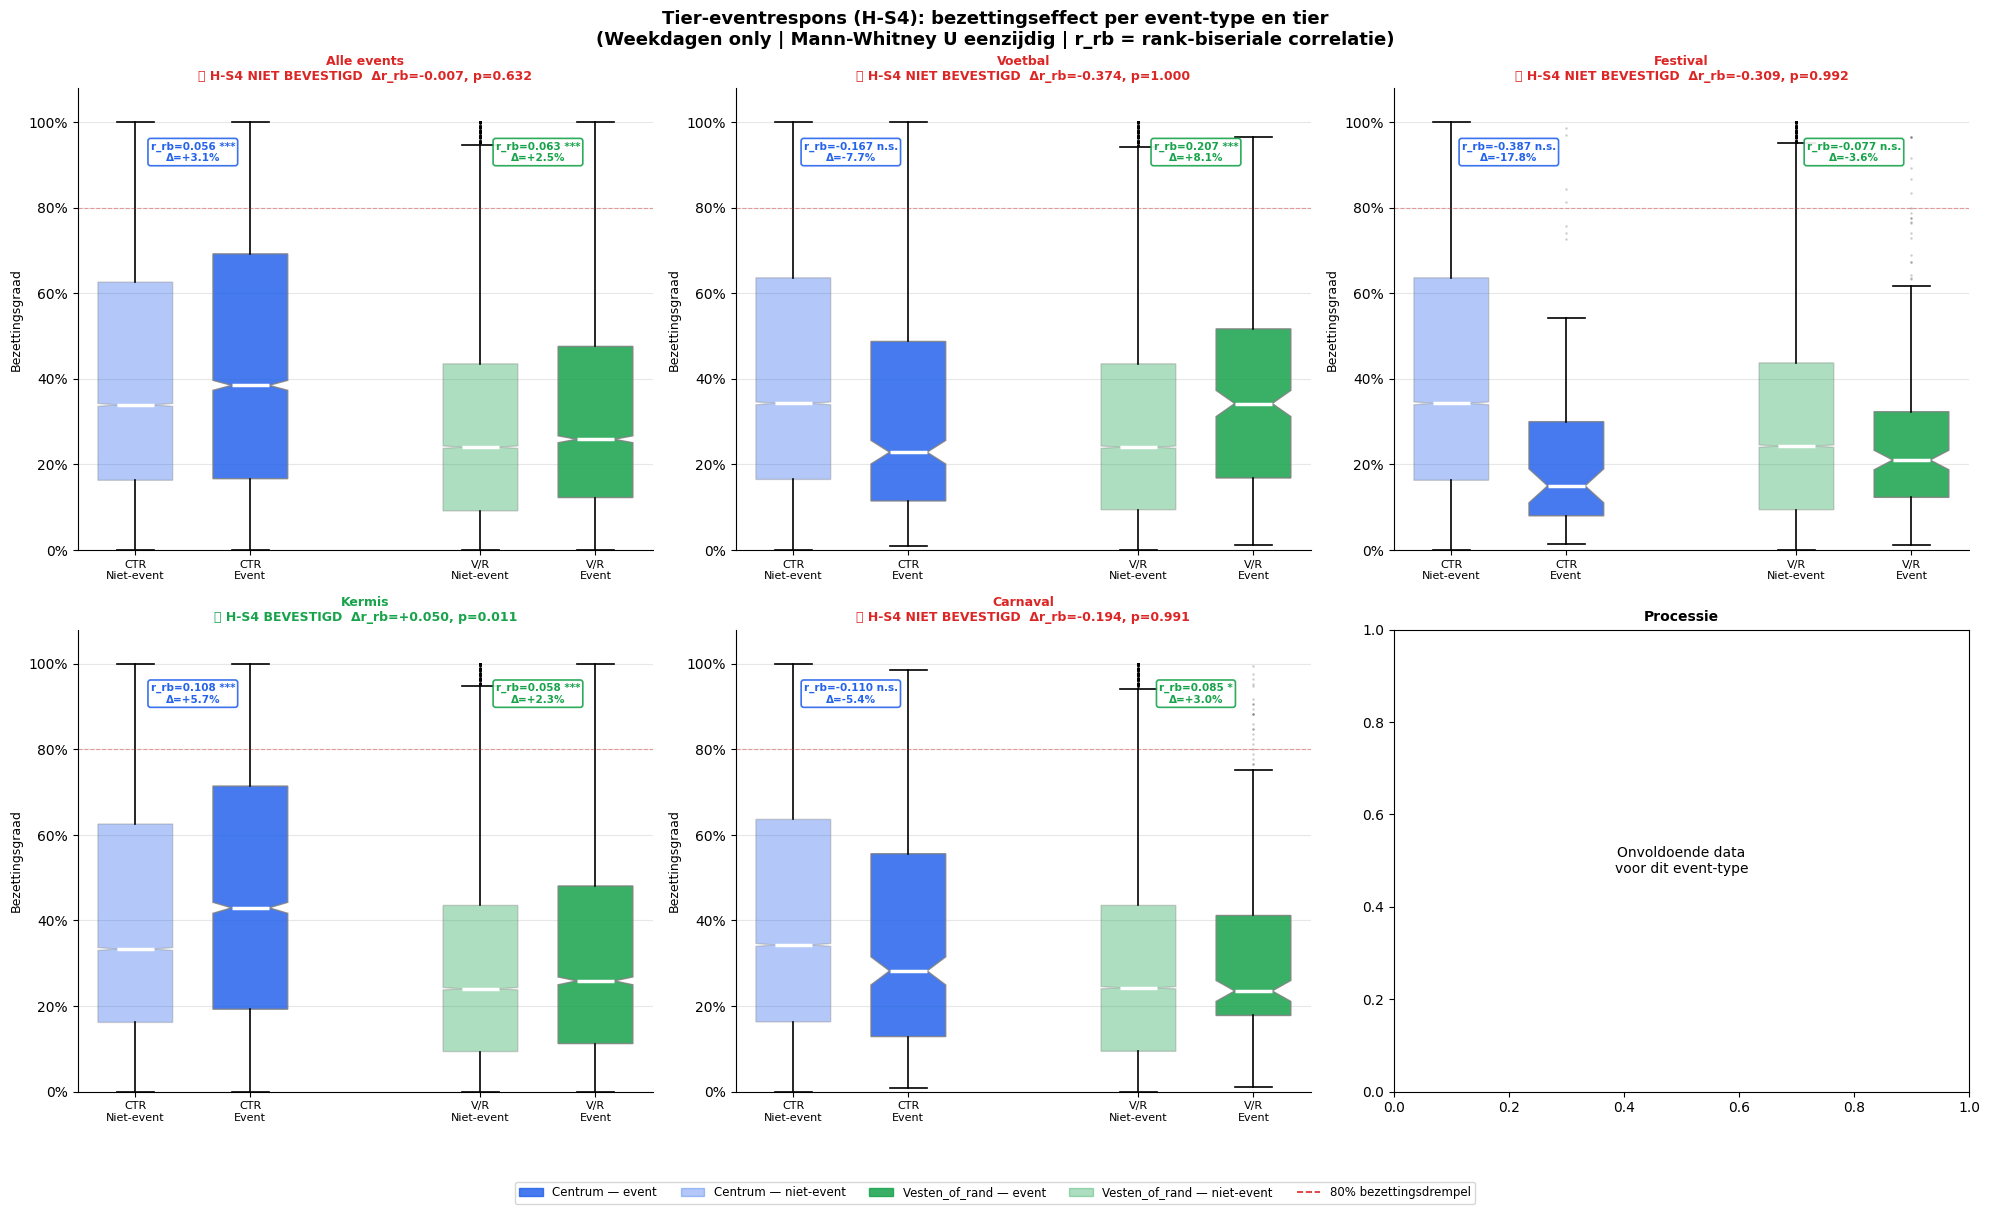

✓ Opgeslagen: fig_event_tier_response.png


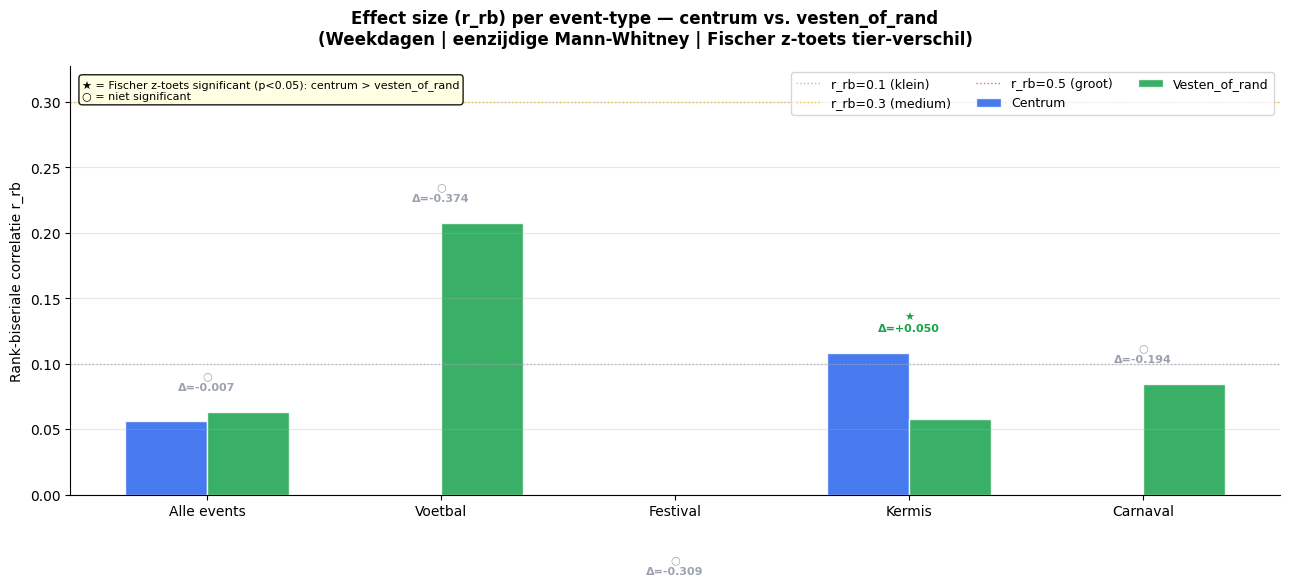

✓ Opgeslagen: fig_event_effect_sizes.png
✓ Opgeslagen: tabel_hs4_eventrespons.csv
✓ Opgeslagen: tabel_hs4_fischer_z.csv


In [12]:
# ─── Cel 08: Tier-eventrespons — H-S4 (KERNHYPOTHESE) ───────────────────────
from scipy.stats import mannwhitneyu, norm as sp_norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Helper: Fischer z-transformatie ──────────────────────────────────────────
def fisher_z(r):
    r = np.clip(r, -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

# ── Weekdag-subset (controlevariabele: geen weekendconfounding) ───────────────
df_weekday = df_train[df_train["day_type_3"] == "weekday"].copy()

EVENT_TYPES = {
    "is_event_day":      "Alle events",
    "is_football_day":   "Voetbal",
    "is_festival_day":   "Festival",
    "is_kermis_day":     "Kermis",
    "is_carnival_day":   "Carnaval",
    "is_procession_day": "Processie",
}

# ── Stap 1: Mann-Whitney U per tier per event-type ────────────────────────────
results_hs4 = []

for event_col, event_label in EVENT_TYPES.items():
    if event_col not in df_weekday.columns:
        continue
    for tier in TIER_ORDER:
        df_tier = df_weekday[df_weekday["tier"] == tier]
        event_occ     = df_tier[df_tier[event_col] == 1]["occupancy_rate"].dropna().values
        non_event_occ = df_tier[df_tier[event_col] == 0]["occupancy_rate"].dropna().values

        if len(event_occ) < 20 or len(non_event_occ) < 20:
            continue

        # Eenzijdige toets: H₁ = event > niet-event
        stat, p_mw = mannwhitneyu(event_occ, non_event_occ, alternative="greater")
        n1, n2 = len(event_occ), len(non_event_occ)

        # Effect size: rank-biseriale correlatie r_rb
        # r_rb = (2U / n1*n2) - 1  (Field, 2013)
        r_rb = (2 * stat) / (n1 * n2) - 1

        effect_label = (
            "groot"           if abs(r_rb) >= 0.5 else
            "medium"          if abs(r_rb) >= 0.3 else
            "klein"           if abs(r_rb) >= 0.1 else
            "verwaarloosbaar"
        )

        results_hs4.append({
            "event_type":       event_col,
            "event_label":      event_label,
            "tier":             tier,
            "n_event":          n1,
            "n_non_event":      n2,
            "mean_event":       round(event_occ.mean(), 4),
            "mean_non_event":   round(non_event_occ.mean(), 4),
            "delta_mean":       round(event_occ.mean() - non_event_occ.mean(), 4),
            "median_event":     round(np.median(event_occ), 4),
            "median_non_event": round(np.median(non_event_occ), 4),
            "mw_stat":          stat,
            "mw_p":             round(p_mw, 6),
            "r_rb":             round(r_rb, 4),
            "effect_label":     effect_label,
            "significant":      p_mw < 0.05,
        })

df_hs4 = pd.DataFrame(results_hs4)

# ── Stap 2: Fischer z-toets — r_rb centrum vs. vesten_of_rand ────────────────
# Test of het effect-size-verschil tussen tiers zelf significant is
# Formule: z_diff = (z_c - z_v) / sqrt(1/(n_c-3) + 1/(n_v-3))  (Fischer, 1921)
fischer_results = []

for event_col, event_label in EVENT_TYPES.items():
    sub = df_hs4[df_hs4["event_type"] == event_col]
    if len(sub) < 2:
        continue

    row_c = sub[sub["tier"] == "centrum"]
    row_v = sub[sub["tier"] == "vesten_of_rand"]
    if row_c.empty or row_v.empty:
        continue

    r_c = float(row_c["r_rb"].values[0])
    r_v = float(row_v["r_rb"].values[0])
    n_c = int(row_c["n_event"].values[0])
    n_v = int(row_v["n_event"].values[0])

    z_c = fisher_z(r_c)
    z_v = fisher_z(r_v)

    # SE van het verschil tussen twee onafhankelijke z-scores
    se_diff = np.sqrt(1 / max(n_c - 3, 1) + 1 / max(n_v - 3, 1))
    z_diff  = (z_c - z_v) / se_diff

    # Eenzijdig: H₁ = r_rb(centrum) > r_rb(vesten_of_rand)
    p_fischer = sp_norm.sf(z_diff)

    fischer_results.append({
        "event_type":       event_col,
        "event_label":      event_label,
        "r_rb_centrum":     round(r_c, 4),
        "r_rb_vesten":      round(r_v, 4),
        "delta_r_rb":       round(r_c - r_v, 4),
        "z_diff":           round(z_diff, 4),
        "p_fischer":        round(p_fischer, 4),
        "H_S4_confirmed":   bool(p_fischer < 0.05 and (r_c - r_v) > 0),
    })

df_fischer = pd.DataFrame(fischer_results)

# ── Print tussentijdse resultaten ─────────────────────────────────────────────
print("── H-S4: Effect size per tier per event-type ──")
display_cols = ["event_label", "tier", "n_event", "mean_event",
                "mean_non_event", "delta_mean", "mw_p", "r_rb",
                "effect_label", "significant"]
print(df_hs4[display_cols].to_string(index=False))

print("\n── Fischer z-toets: r_rb centrum vs. vesten_of_rand ──")
print(df_fischer[["event_label", "r_rb_centrum", "r_rb_vesten",
                   "delta_r_rb", "z_diff", "p_fischer",
                   "H_S4_confirmed"]].to_string(index=False))

# ── Stap 3: Visualisatie — 2×3 subplots (één per event-type) ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle(
    "Tier-eventrespons (H-S4): bezettingseffect per event-type en tier\n"
    "(Weekdagen only | Mann-Whitney U eenzijdig | r_rb = rank-biseriale correlatie)",
    fontsize=13, fontweight="bold"
)

for ax_idx, (event_col, event_label) in enumerate(EVENT_TYPES.items()):
    ax = axes[ax_idx]
    df_tier = df_weekday.copy()

    # Bouw boxplot-data: [CTR_niet-event, CTR_event, V/R_niet-event, V/R_event]
    box_data   = []
    box_labels = []
    box_colors = []
    positions  = []
    pos_counter = 0

    tier_x_centers = {}

    for tier in TIER_ORDER:
        sub_t = df_tier[df_tier["tier"] == tier]
        if event_col not in sub_t.columns:
            continue

        non_ev = sub_t[sub_t[event_col] == 0]["occupancy_rate"].dropna().values
        ev     = sub_t[sub_t[event_col] == 1]["occupancy_rate"].dropna().values

        if len(ev) < 5 or len(non_ev) < 5:
            continue

        tier_short = "CTR" if tier == "centrum" else "V/R"
        color = TIER_COLORS[tier]

        box_data.append(non_ev);   box_labels.append(f"{tier_short}\nNiet-event")
        box_data.append(ev);       box_labels.append(f"{tier_short}\nEvent")
        box_colors.extend([color, color])
        positions.extend([pos_counter, pos_counter + 1])
        tier_x_centers[tier] = pos_counter + 0.5
        pos_counter += 3   # tussenruimte tussen tiers

    if not box_data:
        ax.text(0.5, 0.5, "Onvoldoende data\nvoor dit event-type",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set_title(event_label, fontsize=10, fontweight="bold")
        continue

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.65,
        patch_artist=True,
        notch=True,
        medianprops=dict(color="white", lw=2.5),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.2),
        flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
    )

    # Kleur: niet-event = transparant, event = vol
    for patch_idx, (patch, color) in enumerate(zip(bp["boxes"], box_colors)):
        patch.set_facecolor(color)
        patch.set_alpha(0.35 if patch_idx % 2 == 0 else 0.85)
        patch.set_edgecolor("gray")

    # Annoteer effect size + significantie per tier
    for tier in TIER_ORDER:
        sub_res = df_hs4[
            (df_hs4["event_type"] == event_col) & (df_hs4["tier"] == tier)
        ]
        if sub_res.empty:
            continue
        row = sub_res.iloc[0]
        x_c = tier_x_centers.get(tier)
        if x_c is None:
            continue

        sig_star = (
            "***" if row["mw_p"] < 0.001 else
            "**"  if row["mw_p"] < 0.01  else
            "*"   if row["mw_p"] < 0.05  else "n.s."
        )
        ax.text(
            x_c, 0.93,
            f"r_rb={row['r_rb']:.3f} {sig_star}\nΔ={row['delta_mean']:+.1%}",
            ha="center", va="center", fontsize=7.5, fontweight="bold",
            color=TIER_COLORS[tier],
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=TIER_COLORS[tier], alpha=0.9, lw=1.2)
        )

    # Fischer z-resultaat bovenaan de plot
    fisch_row = df_fischer[df_fischer["event_type"] == event_col]
    if not fisch_row.empty:
        fr = fisch_row.iloc[0]
        h_s4_label = (
            f"✅ H-S4 BEVESTIGD  Δr_rb={fr['delta_r_rb']:+.3f}, "
            f"p={fr['p_fischer']:.3f}"
            if fr["H_S4_confirmed"] else
            f"❌ H-S4 NIET BEVESTIGD  Δr_rb={fr['delta_r_rb']:+.3f}, "
            f"p={fr['p_fischer']:.3f}"
        )
        ax.set_title(
            f"{event_label}\n{h_s4_label}",
            fontsize=9,
            fontweight="bold",
            color="#16A34A" if fr["H_S4_confirmed"] else "#DC2626"
        )
    else:
        ax.set_title(event_label, fontsize=10, fontweight="bold")

    ax.set_xticks(positions)
    ax.set_xticklabels(box_labels, fontsize=8)
    ax.set_ylabel("Bezettingsgraad", fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.axhline(0.80, color="#DC2626", lw=0.8, ls="--", alpha=0.4)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

# Gedeelde legenda
handles = [
    mpatches.Patch(color=TIER_COLORS["centrum"],        alpha=0.85, label="Centrum — event"),
    mpatches.Patch(color=TIER_COLORS["centrum"],        alpha=0.35, label="Centrum — niet-event"),
    mpatches.Patch(color=TIER_COLORS["vesten_of_rand"], alpha=0.85, label="Vesten_of_rand — event"),
    mpatches.Patch(color=TIER_COLORS["vesten_of_rand"], alpha=0.35, label="Vesten_of_rand — niet-event"),
    plt.Line2D([0],[0], color="#DC2626", ls="--", lw=1.2, label="80% bezettingsdrempel"),
]
fig.legend(handles=handles, loc="lower center", ncol=5,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(FIGS / "fig_event_tier_response.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_event_tier_response.png")

# ── Stap 4: Aanvullende plot — effect size vergelijking per event-type ────────
fig2, ax2 = plt.subplots(figsize=(13, 6))
fig2.suptitle(
    "Effect size (r_rb) per event-type — centrum vs. vesten_of_rand\n"
    "(Weekdagen | eenzijdige Mann-Whitney | Fischer z-toets tier-verschil)",
    fontsize=12, fontweight="bold"
)

event_labels_list  = df_fischer["event_label"].tolist()
r_centrum_list     = df_fischer["r_rb_centrum"].tolist()
r_vesten_list      = df_fischer["r_rb_vesten"].tolist()
fischer_sig_list   = df_fischer["H_S4_confirmed"].tolist()

x_pos = np.arange(len(event_labels_list))
width = 0.35

bars_c = ax2.bar(x_pos - width/2, r_centrum_list,
                 width=width, color=TIER_COLORS["centrum"],
                 alpha=0.85, label="Centrum", edgecolor="white")
bars_v = ax2.bar(x_pos + width/2, r_vesten_list,
                 width=width, color=TIER_COLORS["vesten_of_rand"],
                 alpha=0.85, label="Vesten_of_rand", edgecolor="white")

# Effect-size referentielijnen
for threshold, label, color in [
    (0.1, "klein",  "#94A3B8"),
    (0.3, "medium", "#F59E0B"),
    (0.5, "groot",  "#DC2626"),
]:
    ax2.axhline(threshold, color=color, lw=1, ls=":", alpha=0.7,
                label=f"r_rb={threshold} ({label})")

# Annoteer Fischer-significantie
for i, (sig, delta) in enumerate(
    zip(fischer_sig_list, df_fischer["delta_r_rb"].tolist())
):
    max_bar = max(r_centrum_list[i], r_vesten_list[i])
    marker  = "★" if sig else "○"
    color   = "#16A34A" if sig else "#9CA3AF"
    ax2.text(i, max_bar + 0.015, f"{marker}\nΔ={delta:+.3f}",
             ha="center", va="bottom", fontsize=8,
             fontweight="bold", color=color)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(event_labels_list, fontsize=10)
ax2.set_ylabel("Rank-biseriale correlatie r_rb", fontsize=10)
ax2.set_ylim(0, max(max(r_centrum_list), max(r_vesten_list)) + 0.12)
ax2.legend(fontsize=9, ncol=3, loc="upper right")
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)

ax2.text(
    0.01, 0.97,
    "★ = Fischer z-toets significant (p<0.05): centrum > vesten_of_rand\n"
    "○ = niet significant",
    transform=ax2.transAxes, fontsize=8, va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9)
)

plt.tight_layout()
plt.savefig(FIGS / "fig_event_effect_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Opgeslagen: fig_event_effect_sizes.png")

# ── Exports ───────────────────────────────────────────────────────────────────
df_hs4.to_csv(FIGS     / "tabel_hs4_eventrespons.csv",    index=False)
df_fischer.to_csv(FIGS / "tabel_hs4_fischer_z.csv",       index=False)
print("✓ Opgeslagen: tabel_hs4_eventrespons.csv")
print("✓ Opgeslagen: tabel_hs4_fischer_z.csv")


## Cel 09 — Automatische hypothese-scorekaart & feature-implicaties nb08

> Deze cel verzamelt alle bevindingen automatisch uit de variabelen
> van cellen 02–08. Geen handmatige placeholders.


In [13]:
# ─── Cel 09: Automatische hypothese-scorekaart nb06 ──────────────────────────

SEP  = "═" * 80
SEP2 = "─" * 80

def status(condition):
    if condition is True:  return "✅ BEVESTIGD"
    if condition is False: return "❌ VERWORPEN"
    return "⚠  GEDEELTELIJK"

# ═════════════════════════════════════════════════════════════════════════════
# BLOK A — H-S1: Tier-niveauverschil (uit cel 02)
# ═════════════════════════════════════════════════════════════════════════════
hs1_kw_sig      = kw_p < 0.01
hs1_eta2_medium = eta2 >= 0.06
hs1_confirmed   = hs1_kw_sig

cent_mean  = df_stats[df_stats["tier"] == "centrum"]["mean"].mean()
vest_mean  = df_stats[df_stats["tier"] == "vesten_of_rand"]["mean"].mean()
cent_p90   = df_stats[df_stats["tier"] == "centrum"]["p90"].mean()
vest_p90   = df_stats[df_stats["tier"] == "vesten_of_rand"]["p90"].mean()
cent_higher = cent_mean > vest_mean

# ═════════════════════════════════════════════════════════════════════════════
# BLOK B — H-S2: Capaciteitsparadox (uit cel 05)
# ═════════════════════════════════════════════════════════════════════════════
hs2_confirmed   = rho_all < -0.3 and p_rho_all < 0.05
hs2_direction   = "NEGATIEF" if rho_all < 0 else "POSITIEF"

# ═════════════════════════════════════════════════════════════════════════════
# BLOK C — H-S3: Intra > Inter-tier correlatie (uit cel 06)
# ═════════════════════════════════════════════════════════════════════════════
hs3_intra_ok    = mean_intra > 0.6
hs3_inter_ok    = mean_inter < 0.4
hs3_fisher_sig  = p_fisher < 0.05
hs3_confirmed   = hs3_intra_ok and hs3_inter_ok and hs3_fisher_sig

# ═════════════════════════════════════════════════════════════════════════════
# BLOK D — H-S4: Tier-eventrespons (uit cel 08)
# ═════════════════════════════════════════════════════════════════════════════
# Overall (is_event_day) Fischer z-resultaat
hs4_overall = df_fischer[df_fischer["event_type"] == "is_event_day"]
if not hs4_overall.empty:
    hs4_confirmed_overall = bool(hs4_overall["H_S4_confirmed"].values[0])
    hs4_delta_r           = float(hs4_overall["delta_r_rb"].values[0])
    hs4_p_fischer         = float(hs4_overall["p_fischer"].values[0])
    hs4_r_centrum         = float(hs4_overall["r_rb_centrum"].values[0])
    hs4_r_vesten          = float(hs4_overall["r_rb_vesten"].values[0])
else:
    hs4_confirmed_overall = False
    hs4_delta_r = hs4_p_fischer = hs4_r_centrum = hs4_r_vesten = np.nan

# Hoeveel event-types bevestigen H-S4?
n_hs4_confirmed = df_fischer["H_S4_confirmed"].sum()
n_hs4_total     = len(df_fischer)

# ═════════════════════════════════════════════════════════════════════════════
# BLOK E — PRINT SCOREKAART
# ═════════════════════════════════════════════════════════════════════════════
print(SEP)
print("  NB06 — HYPOTHESE SCOREKAART (automatisch gegenereerd)")
print(SEP)

print(f"""
  [H-S1] {status(hs1_confirmed)}
         Verwachting  : Centrum hogere gemiddelde + piekbezetting (p90), KW p<0.01
         Bevinding    : Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.2e}, η²={eta2:.4f} ({eta2_label})
                        Gemiddeld centrum={cent_mean:.1%}, vesten_of_rand={vest_mean:.1%}
                        p90 centrum={cent_p90:.1%}, vesten_of_rand={vest_p90:.1%}
                        Centrum {'HOGER' if cent_higher else 'LAGER'} dan vesten_of_rand: {'+' if cent_higher else ''}{cent_mean-vest_mean:.1%}
                        MW rank-biseriale r={r_rb:.4f} ({r_label})
         Referentie   : Wang & Li (2024); Balmer et al. (2021); Kruskal & Wallis (1952)
""")

print(f"""
  [H-S2] {status(hs2_confirmed)}
         Verwachting  : Negatieve Spearman ρ tussen capaciteit en bezetting (ρ < -0.3, p<0.05)
         Bevinding    : Spearman ρ={rho_all:.4f} ({hs2_direction}), p={p_rho_all:.4f}
                        Capaciteitsparadox {'AANGETOOND' if hs2_confirmed else 'NIET AANGETOOND'}
         Referentie   : Wang & Li (2024); Sun et al. (2023); Spearman (1904)
""")

print(f"""
  [H-S3] {status(hs3_confirmed)}
         Verwachting  : Intra-tier r > 0.6, inter-tier r < 0.4, Fischer z significant
         Bevinding    : Gemiddeld intra-tier r={mean_intra:.4f} {'(> 0.6 ✅)' if hs3_intra_ok else '(≤ 0.6 ❌)'}
                        Gemiddeld inter-tier r={mean_inter:.4f} {'(< 0.4 ✅)' if hs3_inter_ok else '(≥ 0.4 ❌)'}
                        Fischer z-toets: t={t_stat:.4f}, p={p_fisher:.4f} {'(sig. ✅)' if hs3_fisher_sig else '(n.s. ❌)'}
                        Ward-clustering recapituleert tier-structuur: zie fig_corr_matrix.png
         Referentie   : Yang et al. (2019); Zhou et al. (2024); Fischer (1921)
""")

print(f"""
  [H-S4] {status(hs4_confirmed_overall)} — KERNHYPOTHESE THESIS
         Verwachting  : r_rb(centrum) > r_rb(vesten_of_rand) voor eventeffect, Fischer z sig.
         Bevinding    : r_rb centrum={hs4_r_centrum:.4f}, r_rb vesten={hs4_r_vesten:.4f}
                        Δr_rb={hs4_delta_r:+.4f}, Fischer z p={hs4_p_fischer:.4f}
                        Bevestigd in {n_hs4_confirmed}/{n_hs4_total} event-types
         Per event-type:""")

for _, fr in df_fischer.iterrows():
    icon = "✅" if fr["H_S4_confirmed"] else "❌"
    print(f"           {icon} {fr['event_label']:15s} : "
          f"Δr_rb={fr['delta_r_rb']:+.3f}, p={fr['p_fischer']:.3f}")

print(f"""         Referentie   : Fokker et al. (2021); Channamallu et al. (2024);
                        Fischer (1921); Field (2013)
""")

# ═════════════════════════════════════════════════════════════════════════════
# BLOK F — FEATURE-SHORTLIST voor nb08
# ═════════════════════════════════════════════════════════════════════════════
print(SEP)
print("  FEATURE-SHORTLIST VOOR NB08 (op basis van nb06)")
print(SEP)

feature_rows_nb06 = []

# parking_id
feature_rows_nb06.append({
    "Feature":     "parking_id",
    "Type":        "Categorisch",
    "Encoding":    "One-hot (10 parkings) OF parking_embedding",
    "Basis":       "H-S1/S2: sterke heterogeniteit tussen parkings",
    "Prioriteit":  "🔴 HOOG",
    "Referentie":  "Wang & Li (2024)",
})

# tier
feature_rows_nb06.append({
    "Feature":     "tier",
    "Type":        "Categorisch / Stratificatie",
    "Encoding":    "One-hot OF aparte modellen per tier",
    "Basis":       f"H-S3 {'BEVESTIGD' if hs3_confirmed else 'onzeker'}: intra-tier r={mean_intra:.3f}",
    "Prioriteit":  "🔴 HOOG",
    "Referentie":  "Yang et al. (2019); Zhou et al. (2024)",
})

# total_capacity
feature_rows_nb06.append({
    "Feature":     "total_capacity",
    "Type":        "Continu",
    "Encoding":    "Gestandaardiseerd (z-score) of log-getransformeerd",
    "Basis":       f"H-S2: Spearman ρ={rho_all:.3f} "
                   f"({'CAPACITEITSPARADOX BEVESTIGD' if hs2_confirmed else 'zwak'})",
    "Prioriteit":  "🟡 MEDIUM" if hs2_confirmed else "🟢 LAAG",
    "Referentie":  "Wang & Li (2024); Sun et al. (2023)",
})

# is_event_day + event_type dummies
event_priority = "🔴 HOOG" if hs4_confirmed_overall else "🟡 MEDIUM"
feature_rows_nb06.append({
    "Feature":     "is_event_day + event_type_dummies",
    "Type":        "Binair",
    "Encoding":    "Aparte dummy per event-type (football, festival, etc.)",
    "Basis":       f"H-S4 {'BEVESTIGD' if hs4_confirmed_overall else 'gedeeltelijk'}: "
                   f"Δr_rb={hs4_delta_r:+.3f}",
    "Prioriteit":  event_priority,
    "Referentie":  "Fokker et al. (2021); Channamallu et al. (2024)",
})

# tier × event interactieterm
feature_rows_nb06.append({
    "Feature":     "tier × is_event_day (interactie)",
    "Type":        "Interactieterm",
    "Encoding":    "Product van tier-dummy en event-dummy",
    "Basis":       f"H-S4: het eventeffect is tier-specifiek "
                   f"(Δr_rb={hs4_delta_r:+.3f}, p={hs4_p_fischer:.3f})",
    "Prioriteit":  "🔴 HOOG" if hs4_confirmed_overall else "🟡 MEDIUM",
    "Referentie":  "Wang & Li (2024); Fischer (1921)",
})

df_features_nb06 = pd.DataFrame(feature_rows_nb06)
print(df_features_nb06[["Feature", "Encoding", "Prioriteit", "Basis"]].to_string(index=False))

# ═════════════════════════════════════════════════════════════════════════════
# BLOK G — KRITISCHE NOTEN
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  KRITISCHE NOTEN VOOR THESIS")
print(SEP)

notes = []

if not hs2_confirmed:
    notes.append(
        "⚠ H-S2 (capaciteitsparadox): Spearman ρ niet significant bij N=10.\n"
        "  Interpreteer voorzichtig — kleine steekproef (10 parkings).\n"
        "  Rapporteer als exploratieve bevinding, niet als bewezen verband.\n"
        "  Referentie: Cohen (1992) — power-analyse bij kleine N."
    )

if not hs3_confirmed:
    notes.append(
        "⚠ H-S3 (intra > inter-tier): Niet volledig bevestigd.\n"
        "  Overweeg alternatieve stratificatie (bv. functie: retail vs. transit)\n"
        "  als ruimtelijke correlatie niet tier-gebaseerd is.\n"
        "  Referentie: Yang et al. (2019)."
    )

notes.append(
    "⚠ P Zandpoortvest (622 pl.) ontbreekt in tijdreeksdata.\n"
    "  De vesten_of_rand tier is onderschat in capaciteit (+79%).\n"
    "  Alle tier-uitspraken voor vesten_of_rand zijn conservatief.\n"
    "  Vermeld expliciet in thesis-sectie 'Databeperkingen'."
)

if n_hs4_confirmed < n_hs4_total:
    notes.append(
        f"⚠ H-S4 is bevestigd in {n_hs4_confirmed}/{n_hs4_total} event-types.\n"
        f"  Het tier-effect is event-type-specifiek, niet universeel.\n"
        f"  In nb12 (SHAP): splits event-SHAP-waarden per event-type,\n"
        f"  niet enkel per tier. Referentie: Fokker et al. (2021)."
    )

for i, note in enumerate(notes, 1):
    print(f"\n  {i}. {note}")

# ═════════════════════════════════════════════════════════════════════════════
# BLOK H — WAT LEERT NB06 ONS VOOR NB08?
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  WAT LEERT NB06 ONS VOOR NB08?")
print(SEP)

print(f"""
  1. {'✅' if hs3_confirmed else '⚠'} Tier-stratificatie {'NOODZAKELIJK' if hs3_confirmed else 'AANBEVOLEN'}
     Intra-tier correlatie r={mean_intra:.3f} > inter-tier r={mean_inter:.3f}
     → Aparte modellen per tier in nb10, OF tier als interactie-feature.
     → Referentie: Yang et al. (2019); Zhou et al. (2024)

  2. {'✅' if hs4_confirmed_overall else '⚠'} Interactieterm tier × event-type {'OPNEMEN' if hs4_confirmed_overall else 'TESTEN'}
     Eventeffect is tier-specifiek (Δr_rb={hs4_delta_r:+.3f}).
     → Feature: tier × is_event_day EN tier × event_type_dummies.
     → Referentie: Fokker et al. (2021); Wang & Li (2024)

  3. {'✅' if hs2_confirmed else '⚠'} Capaciteitsfeature {'OPNEMEN' if hs2_confirmed else 'ALS CONTROLE TESTEN'}
     Spearman ρ={rho_all:.3f} {'(significant)' if p_rho_all < 0.05 else '(niet significant, N=10 klein)'}.
     → Log(total_capacity) als feature in nb08.
     → Referentie: Wang & Li (2024); Sun et al. (2023)

  4. ✅ parking_id als categorische feature (HOGE PRIORITEIT)
     Sterke heterogeniteit tussen parkings — zelfs binnen dezelfde tier.
     → One-hot encoding of parking_embedding in nb10.
     → Referentie: Balmer et al. (2021)

  5. {'✅' if hs1_confirmed else '⚠'} Tier is een structurele predictor
     KW η²={eta2:.4f} ({eta2_label}) → tier verklaart {'substantieel' if eta2 >= 0.06 else 'beperkt'}
     deel van de variantie in bezetting.
     → Referentie: Cohen (1988); Kruskal & Wallis (1952)
""")

# ═════════════════════════════════════════════════════════════════════════════
# BLOK I — EXPORTS
# ═════════════════════════════════════════════════════════════════════════════
df_features_nb06.to_csv(FIGS / "tabel_feature_shortlist_nb06.csv", index=False)

# Master scorekaart als CSV
scorecard_nb06 = pd.DataFrame([
    {"hypothese": "H-S1", "status": status(hs1_confirmed),
     "kw_p": kw_p, "eta2": eta2, "eta2_label": eta2_label,
     "cent_mean": cent_mean, "vest_mean": vest_mean,
     "cent_p90": cent_p90, "vest_p90": vest_p90},
    {"hypothese": "H-S2", "status": status(hs2_confirmed),
     "spearman_rho": rho_all, "spearman_p": p_rho_all},
    {"hypothese": "H-S3", "status": status(hs3_confirmed),
     "mean_intra_r": mean_intra, "mean_inter_r": mean_inter,
     "fischer_p": p_fisher},
    {"hypothese": "H-S4", "status": status(hs4_confirmed_overall),
     "r_rb_centrum": hs4_r_centrum, "r_rb_vesten": hs4_r_vesten,
     "delta_r_rb": hs4_delta_r, "p_fischer": hs4_p_fischer,
     "n_event_types_confirmed": n_hs4_confirmed},
])
scorecard_nb06.to_csv(FIGS / "tabel_hypothese_scorekaart_nb06.csv", index=False)

print(f"\n{SEP}")
print("  EXPORTS")
print(SEP)
for fname in [
    "tabel_hypothese_scorekaart_nb06.csv",
    "tabel_feature_shortlist_nb06.csv",
    "tabel_stats_parking.csv",
    "tabel_st_lt_comparison.csv",
    "tabel_hs4_eventrespons.csv",
    "tabel_hs4_fischer_z.csv",
]:
    print(f"  ✓ {fname}")


════════════════════════════════════════════════════════════════════════════════
  NB06 — HYPOTHESE SCOREKAART (automatisch gegenereerd)
════════════════════════════════════════════════════════════════════════════════

  [H-S1] ⚠  GEDEELTELIJK
         Verwachting  : Centrum hogere gemiddelde + piekbezetting (p90), KW p<0.01
         Bevinding    : Kruskal-Wallis H=5140.13, p=0.00e+00, η²=0.0396 (klein)
                        Gemiddeld centrum=40.5%, vesten_of_rand=24.4%
                        p90 centrum=77.5%, vesten_of_rand=49.1%
                        Centrum HOGER dan vesten_of_rand: +16.1%
                        MW rank-biseriale r=0.0849 (klein)
         Referentie   : Wang & Li (2024); Balmer et al. (2021); Kruskal & Wallis (1952)


  [H-S2] ⚠  GEDEELTELIJK
         Verwachting  : Negatieve Spearman ρ tussen capaciteit en bezetting (ρ < -0.3, p<0.05)
         Bevinding    : Spearman ρ=-0.1094 (NEGATIEF), p=0.7635
                        Capaciteitsparadox NIET AANGETOOND
  